In [ ]:
# ==== CELL 1: Mount ====
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==== CELL 2: Build pm25_df from metadata (run ONCE; deterministic) ====
import os, shutil
import pandas as pd
import numpy as np

base_dir              = '/content/drive/MyDrive/Data'
metadata_dir          = os.path.join(base_dir, 'Metadata')
reflectance_folder    = os.path.join(base_dir, 'ALL_Reflectance')
transmittance_folder  = os.path.join(base_dir, 'ALL_Transmittance')

def load_and_standardize(fp):
    df = pd.read_excel(fp) if fp.endswith('.xlsx') else pd.read_csv(fp)
    df.rename(columns={"Mass collected on filter": "Mass collected on filter (ug)",
                       "Sampled volume": "Sampled volume (m3)"}, inplace=True)
    return df

combined_df = pd.concat(
    [load_and_standardize(os.path.join(metadata_dir, f))
     for f in os.listdir(metadata_dir) if f.endswith(('.xlsx', '.csv'))],
    ignore_index=True)

combined_df.columns = combined_df.columns.str.strip()
combined_df = combined_df[combined_df["Filter Type"] != "FB"].copy()
combined_df.drop(columns=["Shipment ID (Date)", "Shipment ID", "Cartridge Number",
                          "Barcode", "Project ID", "Lot ID", "Comments"],
                 inplace=True, errors='ignore')

combined_df["Sampled volume (m3)"] = pd.to_numeric(combined_df["Sampled volume (m3)"], errors='coerce')
combined_df["Mass collected on filter (ug)"] = pd.to_numeric(combined_df["Mass collected on filter (ug)"], errors='coerce')
combined_df = combined_df[(combined_df["Sampled volume (m3)"].notna()) &
                          (combined_df["Sampled volume (m3)"] != 0)].copy()
combined_df["PM2.5(ug/m3)"] = combined_df["Mass collected on filter (ug)"] / combined_df["Sampled volume (m3)"]

# PM2.5 filters only, positive values
pm25_df = combined_df[combined_df["Filter Type"] == "PM2.5"].copy()
pm25_df.loc[pm25_df["PM2.5(ug/m3)"] <= 0, "PM2.5(ug/m3)"] = np.nan
pm25_df.dropna(subset=["PM2.5(ug/m3)"], inplace=True)

# Normalize Filter ID ONCE, then drop blanks/dupes -> this is canonical
pm25_df["Filter ID"] = (pm25_df["Filter ID"].astype(str)
                        .str.replace(r'\s*-\s*', '-', regex=True).str.strip())
pm25_df = pm25_df[pm25_df["Filter ID"].notna() & (pm25_df["Filter ID"] != "")]
pm25_df = pm25_df.drop_duplicates(subset="Filter ID", keep="first").reset_index(drop=True)

# Save the CLEAN base (NO blank row baked into the saved file)
pm25_df.to_csv(os.path.join(base_dir, "pm25_df.csv"), index=False)
print(f"Base PM2.5 rows (deterministic): {len(pm25_df)}")

Base PM2.5 rows (deterministic): 2577


In [ ]:
# ==== CELL 3: Compute the FROZEN master ID set ONCE and persist it ====
# This is the single source of truth for "which files to KEEP".
# It is written to disk so the move step never depends on a mutated pm25_df.

master_ids_path = os.path.join(base_dir, "master_valid_ids.txt")

def robust_base_id(filename):
    """USPA-0161-1.Sample.Raw.csv -> USPA-0161-1 (take text before FIRST dot)."""
    return filename.split('.', 1)[0].strip()

# Build master set from the freshly-built pm25_df (NOT a re-loaded/trimmed copy)
master_ids = set(pm25_df["Filter ID"].astype(str).str.strip())

with open(master_ids_path, "w") as f:
    for fid in sorted(master_ids):
        f.write(fid + "\n")
print(f"Frozen master valid IDs: {len(master_ids)} -> {master_ids_path}")

Frozen master valid IDs: 2577 -> /content/drive/MyDrive/Data/master_valid_ids.txt


In [ ]:
# ==== CELL 4: Idempotent, reversible file sorting (replaces old destructive move) ====
# Reads frozen master IDs from disk. Safe to re-run any number of times.

with open(master_ids_path) as f:
    valid_filter_ids = set(line.strip() for line in f if line.strip())

def sync_folder(folder):
    target = os.path.join(folder, "Files_without_PM25")
    os.makedirs(target, exist_ok=True)
    moved, restored = [], []

    # 1) Move OUT files in main folder whose ID is not valid
    for fn in os.listdir(folder):
        p = os.path.join(folder, fn)
        if os.path.isdir(p) or not fn.endswith(".csv"):
            continue
        if robust_base_id(fn) not in valid_filter_ids:
            shutil.move(p, os.path.join(target, fn))
            moved.append(fn)

    # 2) RESTORE files wrongly moved by previous buggy runs (id IS valid now)
    if os.path.isdir(target):
        for fn in os.listdir(target):
            p = os.path.join(target, fn)
            if os.path.isdir(p) or not fn.endswith(".csv"):
                continue
            if robust_base_id(fn) in valid_filter_ids:
                dst = os.path.join(folder, fn)
                if not os.path.exists(dst):     # never overwrite
                    shutil.move(p, dst)
                    restored.append(fn)
    return moved, restored

for label, folder in [("Reflectance", reflectance_folder),
                      ("Transmittance", transmittance_folder)]:
    m, r = sync_folder(folder)
    with open(os.path.join(base_dir, f"moved_files_{label.lower()}.txt"), "w") as f:
        f.writelines(x + "\n" for x in m)
    print(f"{label}: {len(m)} moved out, {len(r)} restored")

Reflectance: 1 moved out, 0 restored
Transmittance: 1 moved out, 0 restored


In [ ]:
# ==== CELL 5: Verify counts are stable & consistent ====
def kept_ids(folder):
    return {robust_base_id(fn) for fn in os.listdir(folder)
            if fn.endswith(".csv") and not os.path.isdir(os.path.join(folder, fn))}

ref_ids  = kept_ids(reflectance_folder)
tran_ids = kept_ids(transmittance_folder)
print(f"Valid IDs (master):       {len(valid_filter_ids)}")
print(f"Kept in Reflectance:      {len(ref_ids)}")
print(f"Kept in Transmittance:    {len(tran_ids)}")
print(f"Have BOTH ref & tran:     {len(ref_ids & tran_ids & valid_filter_ids)}")
print(f"Valid but missing a file: {len(valid_filter_ids - (ref_ids & tran_ids))}")

Valid IDs (master):       2577
Kept in Reflectance:      2021
Kept in Transmittance:    1963
Have BOTH ref & tran:     1961
Valid but missing a file: 616


In [ ]:
# ==== CELL 6: CREATE Average_BLANK (Path B) ====
d = 25e-3
A_s = np.pi * (d ** 2) / 4

def average_blanks(folder, col):
    dfs, found = [], []
    for d_ in [folder, os.path.join(folder, "Files_without_PM25")]:
        if not os.path.isdir(d_): continue
        for fn in os.listdir(d_):
            if fn.upper().startswith("BLANK") and fn.endswith(".csv"):
                df = pd.read_csv(os.path.join(d_, fn)); df.columns = df.columns.str.strip()
                if 'nm' in df.columns and col in df.columns:
                    dfs.append(df[['nm', col]]); found.append(fn)
    if not dfs:
        raise RuntimeError(f"No BLANK files with {col} under {folder}")
    print(f"  {col}: averaged {len(found)} BLANK files")
    return pd.concat(dfs).groupby('nm', as_index=False)[col].mean()

avg_ref  = average_blanks(reflectance_folder,   '%R')
avg_tran = average_blanks(transmittance_folder, '%T')
avg_ref.to_csv(os.path.join(reflectance_folder,   "Average_BLANK_ref.csv"),  index=False)
avg_tran.to_csv(os.path.join(transmittance_folder, "Average_BLANK_tran.csv"), index=False)
print(f"CELL 6 done. ref rows={len(avg_ref)}, tran rows={len(avg_tran)}")

  %R: averaged 23 BLANK files
  %T: averaged 21 BLANK files
CELL 6 done. ref rows=601, tran rows=601


In [ ]:
# ==== CELL 7: Normalize (skips already-normalized) ====
def normalize(folder, avg_df, val_col, out_col):
    a = avg_df.rename(columns={val_col: 'ref_val'}); upd = 0
    for fn in os.listdir(folder):
        if not fn.endswith(".csv") or fn.startswith("Average_BLANK"): continue
        p = os.path.join(folder, fn)
        if os.path.isdir(p): continue
        df = pd.read_csv(p); df.columns = df.columns.str.strip()
        if out_col in df.columns: continue
        if 'nm' in df.columns and val_col in df.columns:
            df = df.merge(a, on='nm', how='left')
            df[out_col] = df[val_col] / df['ref_val']
            df.drop(columns=['ref_val'], inplace=True)
            df.to_csv(p, index=False); upd += 1
    print(f"CELL 7 {folder.split('/')[-1]}: {upd} newly normalized")

normalize(reflectance_folder,   avg_ref,  '%R', 'normalized_%R')
normalize(transmittance_folder, avg_tran, '%T', 'normalized_%T')

CELL 7 ALL_Reflectance: 0 newly normalized
CELL 7 ALL_Transmittance: 0 newly normalized


In [ ]:
# ==== CELL 8: OD + derived columns + final count ====
def build_file_map(folder):
    """filter_id -> actual filename (handles suffixes like .Sample.Cycle1.Raw.csv)."""
    m = {}
    for fn in os.listdir(folder):
        if fn.endswith(".csv") and not fn.startswith("Average_BLANK") \
           and not os.path.isdir(os.path.join(folder, fn)):
            m[robust_base_id(fn)] = fn
    return m

ref_map  = build_file_map(reflectance_folder)
tran_map = build_file_map(transmittance_folder)

def get_od(fid, wl):
    rf, tf = ref_map.get(fid), tran_map.get(fid)
    if rf is None or tf is None:
        return np.nan
    refl  = pd.read_csv(os.path.join(reflectance_folder, rf));   refl.columns  = refl.columns.str.strip()
    trans = pd.read_csv(os.path.join(transmittance_folder, tf)); trans.columns = trans.columns.str.strip()
    if 'normalized_%R' not in refl.columns or 'normalized_%T' not in trans.columns:
        return np.nan
    refl['nm'] = refl['nm'].astype(float); trans['nm'] = trans['nm'].astype(float)
    R = refl.loc[refl['nm'] == wl, 'normalized_%R'].values
    T = trans.loc[trans['nm'] == wl, 'normalized_%T'].values
    if len(R) == 0 or len(T) == 0:
        return np.nan
    return np.log((1 - np.clip(R[0], 0, 0.99)) / max(T[0], 1e-6))

pm25_df = pd.read_csv(os.path.join(base_dir, "pm25_df.csv"))
for wl in (550, 900, 650, 400):
    pm25_df[f'OD@{wl}'] = [get_od(fid, wl) for fid in pm25_df["Filter ID"]]

V = pm25_df['Sampled volume (m3)']
babs = lambda od: (0.48 * (od ** 1.32) * A_s / V) * 1e6
pm25_df['optical_depth']     = pm25_df['OD@550']
pm25_df['b_abs_lambda']      = babs(pm25_df['OD@550'])
pm25_df['MAC_lambda']        = pm25_df['b_abs_lambda'] / pm25_df['PM2.5(ug/m3)']
pm25_df['b_abs_lambda@900']  = babs(pm25_df['OD@900'])
pm25_df['MAC_lambda@900']    = pm25_df['b_abs_lambda@900'] / pm25_df['PM2.5(ug/m3)']
pm25_df['f_mass_EC']         = pm25_df['MAC_lambda@900'] / 4.58
pm25_df['Black_carbon_mass'] = pm25_df['f_mass_EC'] * pm25_df['PM2.5(ug/m3)']
pm25_df['Non_Black_carbon_mass'] = pm25_df['PM2.5(ug/m3)'] - pm25_df['Black_carbon_mass']
pm25_df['b_abs_lambda@650']  = babs(pm25_df['OD@650'])
pm25_df['b_abs_lambda@400']  = babs(pm25_df['OD@400'])
for w in (400, 550, 650):
    pm25_df[f'b_abs_BC@{w}']  = pm25_df['b_abs_lambda@900'] * (900 / w)
    pm25_df[f'b_abs_BrC@{w}'] = pm25_df['b_abs_lambda'] - pm25_df[f'b_abs_BC@{w}']
pm25_df['AAE@400_650'] = -np.log(pm25_df['b_abs_lambda@400'] / pm25_df['b_abs_lambda@650']) / np.log(400/650)
pm25_df['AAE@650_900'] = -np.log(pm25_df['b_abs_lambda@650'] / pm25_df['b_abs_lambda@900']) / np.log(650/900)

key = ['optical_depth','b_abs_lambda','MAC_lambda','OD@900','b_abs_lambda@900',
       'MAC_lambda@900','f_mass_EC','Black_carbon_mass','OD@650','OD@400',
       'AAE@400_650','AAE@650_900']
pm25_df = pm25_df.dropna(subset=key).reset_index(drop=True)
pm25_df.to_csv(os.path.join(base_dir, "pm25_df.csv"), index=False)
print(f"CELL 8 done. FINAL deterministic rows = {len(pm25_df)}")

CELL 8 done. FINAL deterministic rows = 1951


In [ ]:
# ==== CELL 9:Find the remaining ~20 dropped filters ====
import pandas as pd, numpy as np
with open(master_ids_path) as f:
    master = set(l.strip() for l in f if l.strip())

def kept(folder):
    return {robust_base_id(fn) for fn in os.listdir(folder)
            if fn.endswith(".csv") and not fn.startswith("Average_BLANK")
            and not os.path.isdir(os.path.join(folder, fn))}
have_both = kept(reflectance_folder) & kept(transmittance_folder) & master

final = set(pd.read_csv(os.path.join(base_dir,"pm25_df.csv"))['Filter ID'])
dropped = sorted(have_both - final)
print(f"have_both={len(have_both)}  final={len(final)}  dropped={len(dropped)}")

for fid in dropped:
    rf, tf = ref_map.get(fid), tran_map.get(fid)
    refl  = pd.read_csv(os.path.join(reflectance_folder, rf));   refl.columns=refl.columns.str.strip()
    trans = pd.read_csv(os.path.join(transmittance_folder, tf)); trans.columns=trans.columns.str.strip()
    if 'normalized_%R' not in refl.columns or 'normalized_%T' not in trans.columns:
        print(f"{fid}: NOT NORMALIZED (R cols={list(refl.columns)}, T cols={list(trans.columns)})"); continue
    refl['nm']=refl['nm'].astype(float); trans['nm']=trans['nm'].astype(float)
    msg=[]
    for wl in (550,900,650,400):
        R=refl.loc[refl['nm']==wl,'normalized_%R'].values
        T=trans.loc[trans['nm']==wl,'normalized_%T'].values
        if len(R)==0 or len(T)==0: msg.append(f"no nm={wl}")
        elif R[0]>=1: msg.append(f"R@{wl}={R[0]:.3f}>=1")
        elif T[0]<=0: msg.append(f"T@{wl}={T[0]:.3f}<=0")
    # also check the AAE log domain (negative b_abs -> nan)
    print(f"{fid}: {msg if msg else 'OD ok -> likely AAE/log-domain (negative b_abs from OD<0)'}")

have_both=1961  final=1951  dropped=10
CAHA-0259-3: ['R@550=1.080>=1', 'R@900=1.082>=1', 'R@650=1.082>=1', 'R@400=1.104>=1']
INKA-0283-3: ['R@550=1.076>=1', 'R@900=1.071>=1', 'R@650=1.079>=1', 'R@400=1.044>=1']
KRSE-0061-5: ['R@550=1.066>=1', 'R@900=1.069>=1', 'R@650=1.068>=1', 'R@400=1.058>=1']
KRUL-0034-2: ['R@550=1.107>=1', 'R@900=1.104>=1', 'R@650=1.108>=1', 'R@400=1.096>=1']
NGIL-0347-3: ['R@550=1.087>=1', 'R@900=1.093>=1', 'R@650=1.088>=1', 'R@400=1.108>=1']
NGIL-0348-4: ['R@550=1.082>=1', 'R@900=1.079>=1', 'R@650=1.082>=1', 'R@400=1.089>=1']
TWTA-0024-8: ['R@550=1.086>=1', 'R@900=1.087>=1', 'R@650=1.086>=1', 'R@400=1.140>=1']
TWTA-0038-6: ['R@550=1.084>=1', 'R@900=1.091>=1', 'R@650=1.087>=1', 'R@400=1.108>=1']
TWTA-0070-6: OD ok -> likely AAE/log-domain (negative b_abs from OD<0)
USPA-0041-1: OD ok -> likely AAE/log-domain (negative b_abs from OD<0)


In [ ]:
## finding bug
import os
fid = "ILNZ-0612-4"
for folder in [reflectance_folder, transmittance_folder]:
    hits = [f for f in os.listdir(folder) if f.startswith(fid+".") or f.split('.',1)[0]==fid]
    print(folder.split('/')[-1], "->", hits)

ALL_Reflectance -> ['ILNZ-0612-4.Sample.Cycle1.Raw.csv']
ALL_Transmittance -> ['ILNZ-0612-4.Sample.Raw.csv']


In [ ]:
# ==== CELL 10: Add Location + build CLEAN analysis frame (fixes alignment) ====
import pandas as pd
from sklearn.preprocessing import StandardScaler

df_pm25 = pd.read_csv(os.path.join(base_dir, 'pm25_df.csv'))

location_map = {
    'AEAZ':'Abu Dhabi, UAE','AUMN':'Melbourne, Australia','ARCB':'Buenos Aires, Argentina',
    'BDDU':'Dhaka, Bangladesh','BIBU':'Bujumbura, Burundi','CADO':'Downsview, Canada',
    'CAHA':'Halifax, Canada','CAKE':'Kelowna, Canada','CALE':'Lethbridge, Canada',
    'CASH':'Sherbrooke, Canada','CHTS':'Beijing, China','CODC':'Palmira, Colombia',
    'CLST':'Santiago, Chile','CLTA':'Talca, Chile','ETBI':'Bishoftu, Ethiopia',
    'ETAD':'Addis Ababa, Ethiopia','IDBD':'Bandung, Indonesia','ILHA':'Haifa, Israel',
    'ILNZ':'Rehovot, Israel','INDH':'Delhi, India','INJA':'Jaipur, India','INKA':'Kanpur, India',
    'KRSE':'Seoul, South Korea','KRUL':'Ulsan, South Korea','MXMC':'Mexico City, Mexico',
    'NGIL':'Ilorin, Nigeria','PHMO':'Manila, Philippines','PRFJ':'Fajardo, Puerto Rico',
    'SGSU':'Singapore, Singapore','TWKA':'Kaohsiung, Taiwan','TWTA':'Taipei, Taiwan',
    'USBA':'Baltimore, USA','USBO':'Bondville, USA','USMC':'Mammoth Cave, USA',
    'USPA':'Pasadena, USA','USNO':'Norman, USA','VNHN':'Hanoi, Vietnam',
    'ZAJB':'Johannesburg, South Africa','ZAPR':'Pretoria, South Africa',
}
df_pm25['Location'] = df_pm25['Filter ID'].str[:4].map(location_map)

# report unmapped BEFORE dropping (so you can add codes if needed)
unmapped = df_pm25[df_pm25['Location'].isna()]['Filter ID'].str[:4].unique()
print("Unmapped site codes:", unmapped)

numeric_cols = ['b_abs_lambda', 'MAC_lambda', 'AAE@400_650', 'AAE@650_900']

# CRITICAL: build ONE clean frame, drop NaNs once, reset index.
# Everything downstream (X, labels, df_pm25) shares this exact same set of rows.
df_pm25 = df_pm25.dropna(subset=['Location'] + numeric_cols).reset_index(drop=True)
df_pm25.to_csv(os.path.join(base_dir, 'pm25_df.csv'), index=False)
print("Rows used for clustering:", len(df_pm25))

# scaled features (same index as df_pm25)
scaler = StandardScaler()
X = scaler.fit_transform(df_pm25[numeric_cols].values)

Unmapped site codes: []
Rows used for clustering: 1951


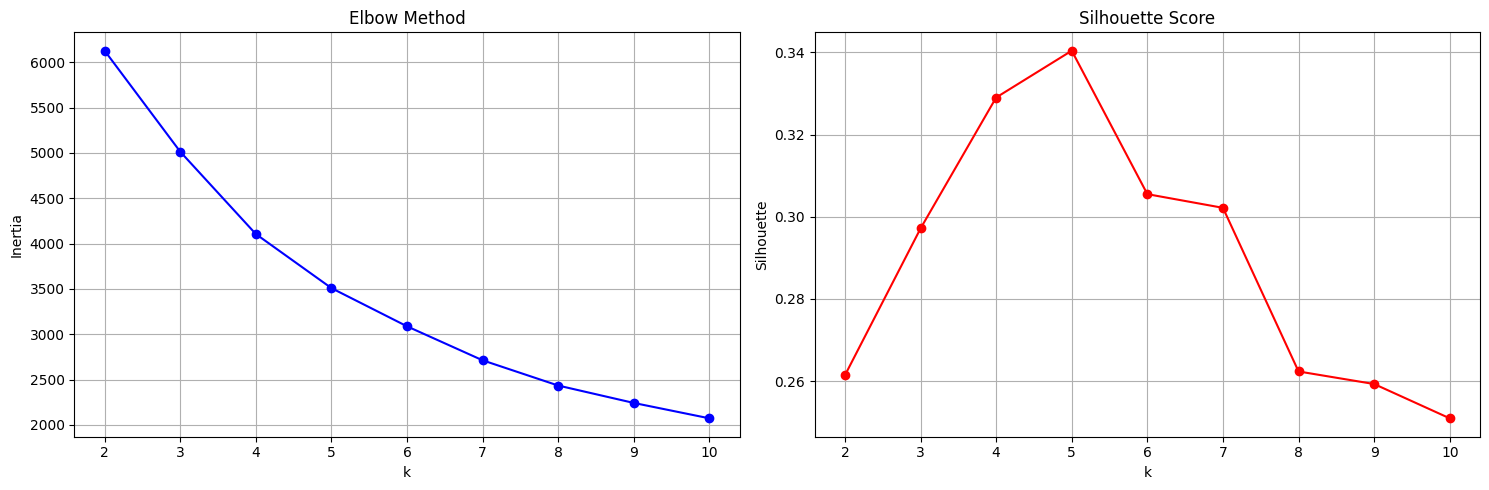

Recommended k (silhouette): 5
silhouette_avg: 0.3404112753352899
✅ Saved pm25_df_with_clusters.csv  rows = 1951, k = 5
         b_abs_lambda_mean  b_abs_lambda_std  MAC_lambda_mean  MAC_lambda_std  AAE@400_650_mean  AAE@400_650_std  AAE@650_900_mean  AAE@650_900_std  Count
Cluster                                                                                                                                                   
0                26.564036         13.116354         1.653296        0.559807          4.223104         1.140783          1.373320         0.247781    219
1                50.850495         19.956317         1.648119        0.632981          0.888820         1.060772          0.972107         0.203896    280
2                 7.837450          4.098900         1.566919        0.677520          1.535627         0.873620          2.312748         0.587377    184
3                17.356409          6.610423         1.334302        0.515211          0.890034         0.

In [ ]:
# ==== CELL 11: KMeans with auto-selected k (silhouette) ====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

def find_optimal_clusters(data, max_clusters=10):
    k_range = range(2, max_clusters + 1)
    inertias, sil = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(data)
        inertias.append(km.inertia_)
        sil.append(silhouette_score(data, km.labels_))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(list(k_range), inertias, 'bo-'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
    ax1.set_title('Elbow Method'); ax1.grid(True)
    ax2.plot(list(k_range), sil, 'ro-'); ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')
    ax2.set_title('Silhouette Score'); ax2.grid(True)
    plt.tight_layout(); plt.show()
    best = list(k_range)[int(np.argmax(sil))]
    print(f"Recommended k (silhouette): {best}")
    return best

n_clusters = find_optimal_clusters(X)

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300,
                n_init=10, random_state=42)
labels = kmeans.fit_predict(X)
print("silhouette_avg:", silhouette_score(X, labels))

# labels align with df_pm25 (same cleaned frame from Cell 9)
df_pm25['Cluster'] = labels
df_pm25.to_csv(os.path.join(base_dir, "pm25_df_with_clusters.csv"), index=False)
print(f"✅ Saved pm25_df_with_clusters.csv  rows = {len(df_pm25)}, k = {n_clusters}")

cluster_summary = df_pm25.groupby('Cluster').agg(
    b_abs_lambda_mean=('b_abs_lambda','mean'), b_abs_lambda_std=('b_abs_lambda','std'),
    MAC_lambda_mean=('MAC_lambda','mean'),     MAC_lambda_std=('MAC_lambda','std'),
    **{'AAE@400_650_mean':('AAE@400_650','mean'),'AAE@400_650_std':('AAE@400_650','std'),
       'AAE@650_900_mean':('AAE@650_900','mean'),'AAE@650_900_std':('AAE@650_900','std')},
    Count=('Cluster','count'))
print(cluster_summary.to_string())

In [ ]:
# ==== CELL 11b: build a color list sized to n_clusters ====
import matplotlib.cm as cm
_base = ['#FFD700', 'red', 'blue', 'green', 'magenta', 'cyan', 'orange', 'purple']
if n_clusters <= len(_base):
    CUSTOM_COLORS = _base[:n_clusters]
else:
    CUSTOM_COLORS = [cm.tab10(i % 10) for i in range(n_clusters)]
print("colors:", CUSTOM_COLORS)

colors: ['#FFD700', 'red', 'blue', 'green', 'magenta']


In [ ]:
!pip install -q "kaleido==0.2.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 5.4 MB/s eta 0:00:00


In [ ]:
# ==== CELL 12: World map — dominant cluster per site (self-contained) ====
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import os
try:
    import kaleido
except ImportError:
    os.system("pip install -q kaleido")
df_clusters = pd.read_csv(os.path.join(base_dir, "pm25_df_with_clusters.csv"))
n_clusters = df_clusters['Cluster'].nunique()

SITE_COORDS = {
    'Abu Dhabi, UAE':(24.45,54.38),'Melbourne, Australia':(-37.81,144.96),
    'Buenos Aires, Argentina':(-34.60,-58.38),'Dhaka, Bangladesh':(23.81,90.41),
    'Bujumbura, Burundi':(-3.36,29.36),'Downsview, Canada':(43.75,-79.47),
    'Halifax, Canada':(44.65,-63.58),'Kelowna, Canada':(49.89,-119.50),
    'Lethbridge, Canada':(49.69,-112.84),'Sherbrooke, Canada':(45.40,-71.89),
    'Beijing, China':(39.90,116.41),'Palmira, Colombia':(3.54,-76.30),
    'Santiago, Chile':(-33.45,-70.67),'Talca, Chile':(-35.43,-71.65),
    'Bishoftu, Ethiopia':(8.75,38.98),'Addis Ababa, Ethiopia':(9.03,38.74),
    'Bandung, Indonesia':(-6.92,107.61),'Haifa, Israel':(32.79,34.99),
    'Rehovot, Israel':(31.89,34.81),'Delhi, India':(28.61,77.21),
    'Jaipur, India':(26.91,75.79),'Kanpur, India':(26.45,80.33),
    'Seoul, South Korea':(37.57,126.98),'Ulsan, South Korea':(35.54,129.31),
    'Mexico City, Mexico':(19.43,-99.13),'Ilorin, Nigeria':(8.50,4.55),
    'Manila, Philippines':(14.60,120.98),'Fajardo, Puerto Rico':(18.33,-65.65),
    'Singapore, Singapore':(1.35,103.82),'Kaohsiung, Taiwan':(22.63,120.30),
    'Taipei, Taiwan':(25.03,121.57),'Baltimore, USA':(39.29,-76.61),
    'Bondville, USA':(40.05,-88.37),'Mammoth Cave, USA':(37.19,-86.10),
    'Pasadena, USA':(34.15,-118.14),'Norman, USA':(35.22,-97.44),
    'Hanoi, Vietnam':(21.03,105.85),'Johannesburg, South Africa':(-26.20,28.05),
    'Pretoria, South Africa':(-25.75,28.19),
}

# --- Per-site: total samples + dominant cluster ---
site_total = df_clusters.groupby('Location').size().rename('Total_Samples')
dom = (df_clusters.groupby(['Location','Cluster']).size()
       .reset_index(name='n')
       .sort_values('n', ascending=False)
       .drop_duplicates('Location')
       .set_index('Location')['Cluster'].rename('Dominant_Cluster'))

site_stats = pd.concat([site_total, dom], axis=1).reset_index()
site_stats['Latitude']  = site_stats['Location'].map(lambda x: SITE_COORDS.get(x, (None,None))[0])
site_stats['Longitude'] = site_stats['Location'].map(lambda x: SITE_COORDS.get(x, (None,None))[1])

missing = site_stats[site_stats['Latitude'].isna()]['Location'].tolist()
if missing:
    print("⚠️ No coordinates for:", missing)
site_plot = site_stats.dropna(subset=['Latitude','Longitude']).copy()

# --- Per-site cluster percentage breakdown ---
counts = df_clusters.groupby(['Location','Cluster']).size().reset_index(name='n')
counts['pct'] = counts.groupby('Location')['n'].transform(lambda s: (s/s.sum()*100).round(1))
pct = counts[['Location','Cluster','pct']]
pct_wide = pct.pivot(index='Location', columns='Cluster', values='pct').fillna(0)
pct_wide.columns = [f'Cluster {chr(65+int(c))} %' for c in pct_wide.columns]
print("=== Cluster % share per site ===")
print(pct_wide.to_string())

dom_pct = (pct.sort_values('pct', ascending=False)
           .drop_duplicates('Location').set_index('Location')['pct'])
site_plot['Dominant_%'] = site_plot['Location'].map(dom_pct)

def breakdown_str(loc):
    row = pct_wide.loc[loc]
    return "  ".join(f"{c.replace(' %','').replace('Cluster ','')}:{v:.0f}%"
                     for c, v in row.items() if v > 0)
site_plot['Breakdown'] = site_plot['Location'].map(breakdown_str)

# --- Cluster labels A,B,C… + colors sized to n_clusters ---
site_plot['Cluster_Label'] = site_plot['Dominant_Cluster'].map(lambda i: f'Cluster {chr(65+int(i))}')
base_colors = ['#FFD700', 'red', 'blue', 'green', 'magenta', 'cyan', 'orange', 'purple',
               '#8B4513','#FFA500','#800080','#008080']
color_map = {f'Cluster {chr(65+i)}': base_colors[i % len(base_colors)] for i in range(n_clusters)}

# --- Map ---
fig = px.scatter_geo(
    site_plot, lat='Latitude', lon='Longitude',
    color='Cluster_Label', size='Total_Samples', hover_name='Location',
    hover_data={'Dominant_Cluster':True,'Dominant_%':True,'Breakdown':True,
                'Total_Samples':True,'Latitude':False,'Longitude':False},
    color_discrete_map=color_map,
    title="Black Carbon — Site-Based Dominant Cluster")

fig.update_traces(marker=dict(opacity=0.9, line=dict(width=1.5, color='white'),
                              sizemin=6, sizeref=site_plot['Total_Samples'].max()/40,
                              sizemode='area'),
                  selector=dict(mode='markers'))

# Site name labels (white halo + black text)
for _, r in site_plot.iterrows():
    name = r['Location'].split(',')[0]
    for col, op in [('white',1.0), ('black',0.9)]:
        fig.add_trace(go.Scattergeo(
            lat=[r['Latitude']], lon=[r['Longitude']], mode='text', text=[name],
            textfont=dict(size=9, color=col, family='Arial'),
            textposition='top center', showlegend=False, hoverinfo='skip', opacity=op))

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth',
             showland=True, landcolor='lightgray'),
    height=700,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01,
                bgcolor="rgba(255,255,255,0.9)", bordercolor="black", borderwidth=1))
#category_orders={'Cluster_Label': sorted(site_plot['Cluster_Label'].unique())},   ############ re-order
fig.show()

# --- Save to Drive ---
out_dir = os.path.join(base_dir, "maps")
os.makedirs(out_dir, exist_ok=True)
png_path  = os.path.join(out_dir, "site_cluster_map.png")
html_path = os.path.join(out_dir, "site_cluster_map.html")
fig.write_html(html_path)
try:
    fig.write_image(png_path, width=1400, height=700, scale=2)
    print(f"Saved PNG  -> {png_path}")
except Exception as e:
    print(f"PNG export failed ({e}). HTML saved instead.")
print(f"Saved HTML -> {html_path}")

print("\n=== Sites per dominant cluster ===")
print(site_plot['Dominant_Cluster'].value_counts().sort_index().to_string())
print(f"\nTotal sites mapped: {len(site_plot)}")

=== Cluster % share per site ===
                            Cluster A %  Cluster B %  Cluster C %  Cluster D %  Cluster E %
Location                                                                                   
Abu Dhabi, UAE                      8.6         16.0          0.0         75.3          0.0
Addis Ababa, Ethiopia               6.3         88.0          0.0          2.8          2.8
Bandung, Indonesia                 35.7         50.0          0.0         14.3          0.0
Beijing, China                      0.0          0.8          6.4         92.8          0.0
Bujumbura, Burundi                 35.6         20.0          0.0         44.4          0.0
Delhi, India                        2.9         71.4          0.0         14.3         11.4
Dhaka, Bangladesh                   0.0         77.6          0.0         22.4          0.0
Fajardo, Puerto Rico                0.0          0.0         42.5         55.0          2.5
Haifa, Israel                      26.8        

Saved PNG  -> /content/drive/MyDrive/Data/maps/site_cluster_map.png
Saved HTML -> /content/drive/MyDrive/Data/maps/site_cluster_map.html

=== Sites per dominant cluster ===
Dominant_Cluster
1     6
2     3
3    16

Total sites mapped: 25


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
for k in range(2,8):
    lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    print(k, round(silhouette_score(X, lab),4))

2 0.2614
3 0.2971
4 0.329
5 0.3404
6 0.3055
7 0.3022


In [ ]:
# ═══ : World map (no location labels) — separate ═══
import pandas as pd
import plotly.express as px
import os
try:
    import kaleido
except ImportError:
    os.system("pip install -q kaleido")

df_clusters = pd.read_csv(os.path.join(base_dir, "pm25_df_with_clusters.csv"))
n_clusters = df_clusters['Cluster'].nunique()

SITE_COORDS = {
    'Abu Dhabi, UAE':(24.45,54.38),'Melbourne, Australia':(-37.81,144.96),
    'Buenos Aires, Argentina':(-34.60,-58.38),'Dhaka, Bangladesh':(23.81,90.41),
    'Bujumbura, Burundi':(-3.36,29.36),'Downsview, Canada':(43.75,-79.47),
    'Halifax, Canada':(44.65,-63.58),'Kelowna, Canada':(49.89,-119.50),
    'Lethbridge, Canada':(49.69,-112.84),'Sherbrooke, Canada':(45.40,-71.89),
    'Beijing, China':(39.90,116.41),'Palmira, Colombia':(3.54,-76.30),
    'Santiago, Chile':(-33.45,-70.67),'Talca, Chile':(-35.43,-71.65),
    'Bishoftu, Ethiopia':(8.75,38.98),'Addis Ababa, Ethiopia':(9.03,38.74),
    'Bandung, Indonesia':(-6.92,107.61),'Haifa, Israel':(32.79,34.99),
    'Rehovot, Israel':(31.89,34.81),'Delhi, India':(28.61,77.21),
    'Jaipur, India':(26.91,75.79),'Kanpur, India':(26.45,80.33),
    'Seoul, South Korea':(37.57,126.98),'Ulsan, South Korea':(35.54,129.31),
    'Mexico City, Mexico':(19.43,-99.13),'Ilorin, Nigeria':(8.50,4.55),
    'Manila, Philippines':(14.60,120.98),'Fajardo, Puerto Rico':(18.33,-65.65),
    'Singapore, Singapore':(1.35,103.82),'Kaohsiung, Taiwan':(22.63,120.30),
    'Taipei, Taiwan':(25.03,121.57),'Baltimore, USA':(39.29,-76.61),
    'Bondville, USA':(40.05,-88.37),'Mammoth Cave, USA':(37.19,-86.10),
    'Pasadena, USA':(34.15,-118.14),'Norman, USA':(35.22,-97.44),
    'Hanoi, Vietnam':(21.03,105.85),'Johannesburg, South Africa':(-26.20,28.05),
    'Pretoria, South Africa':(-25.75,28.19),
}

site_total = df_clusters.groupby('Location').size().rename('Total_Samples')
dom = (df_clusters.groupby(['Location','Cluster']).size()
       .reset_index(name='n').sort_values('n', ascending=False)
       .drop_duplicates('Location').set_index('Location')['Cluster'].rename('Dominant_Cluster'))
site_stats = pd.concat([site_total, dom], axis=1).reset_index()
site_stats['Latitude']  = site_stats['Location'].map(lambda x: SITE_COORDS.get(x,(None,None))[0])
site_stats['Longitude'] = site_stats['Location'].map(lambda x: SITE_COORDS.get(x,(None,None))[1])
site_plot = site_stats.dropna(subset=['Latitude','Longitude']).copy()

site_plot['Cluster_Label'] = site_plot['Dominant_Cluster'].map(lambda i: f'Cluster {chr(65+int(i))}')
base_colors = ['#FFD700', 'red', 'blue', 'green', 'magenta', 'cyan', 'orange', 'purple',
               '#8B4513','#FFA500','#800080','#008080']
color_map = {f'Cluster {chr(65+i)}': base_colors[i % len(base_colors)] for i in range(n_clusters)}

fig = px.scatter_geo(
    site_plot, lat='Latitude', lon='Longitude',
    color='Cluster_Label', size='Total_Samples', hover_name='Location',
    color_discrete_map=color_map,
    title="Aerosol Absorption — Site-Based Dominant Cluster")

fig.update_traces(marker=dict(opacity=0.9, line=dict(width=1.5, color='white'),
                              sizemin=6, sizeref=site_plot['Total_Samples'].max()/40,
                              sizemode='area'),
                  selector=dict(mode='markers'))

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth',
             showland=True, landcolor='lightgray'),
    height=700,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01,
                bgcolor="rgba(255,255,255,0.9)", bordercolor="black", borderwidth=1))
fig.show()

# --- Save image ---
out_dir = os.path.join(base_dir, "maps")
os.makedirs(out_dir, exist_ok=True)
png_path  = os.path.join(out_dir, "site_cluster_map_nolabels.png")
html_path = os.path.join(out_dir, "site_cluster_map_nolabels.html")
fig.write_html(html_path)
try:
    fig.write_image(png_path, width=1400, height=700, scale=2)
    print(f"Saved PNG  -> {png_path}")
except Exception as e:
    print(f"PNG export failed ({e}). HTML saved instead.")
print(f"Saved HTML -> {html_path}")

Saved PNG  -> /content/drive/MyDrive/Data/maps/site_cluster_map_nolabels.png
Saved HTML -> /content/drive/MyDrive/Data/maps/site_cluster_map_nolabels.html


In [ ]:
# ==== CELL 13: Per-site cluster pie charts from REAL data → save to Drive/piechart ====
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_pm25 = pd.read_csv(os.path.join(base_dir, "pm25_df_with_clusters.csv"))
n_clusters = df_pm25['Cluster'].nunique()

# real counts: rows = Location, cols = cluster 0..k-1, values = #filters
counts = df_pm25.groupby(['Location', 'Cluster']).size().unstack(fill_value=0)
print(counts)

# colors/labels sized to k (same palette as the map)
base_colors = ['#FF0000','#00AA00','#0066FF','#FFD700','#FF00FF','#00FFFF',
               '#8B4513','#FFA500','#800080','#008080']
COLORS = {c: base_colors[i % len(base_colors)] for i, c in enumerate(sorted(counts.columns))}
LABELS = {c: f'Cluster {chr(65 + int(c))}' for c in sorted(counts.columns)}

# output folder on Drive
out_dir = os.path.join(base_dir, "piechart")
os.makedirs(out_dir, exist_ok=True)

saved = 0
for location, row in counts.iterrows():
    slices = {c: int(row[c]) for c in counts.columns if row[c] > 0}
    if not slices:
        print(f"Skipping {location}: no data")
        continue

    keys   = list(slices.keys())
    values = [slices[k] for k in keys]
    colors = [COLORS[k] for k in keys]
    total  = sum(values)

    fig, ax = plt.subplots(figsize=(5, 5), facecolor='none')
    ax.set_facecolor('none')
    ax.pie(values, labels=None, colors=colors, startangle=90,
           wedgeprops=dict(linewidth=1.4, edgecolor='white'))
    ax.set_title(f"{location}  (n={total})", fontsize=13, fontweight='bold',
                 pad=14, color='black')

    legend_patches = [mpatches.Patch(color=COLORS[k],
                      label=f"{LABELS[k]}: {slices[k]} ({slices[k]/total*100:.0f}%)")
                      for k in keys]
    ax.legend(handles=legend_patches, loc='center left',
              bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
    ax.set_aspect('equal')

    # safe filename
    safe = location.replace(',', '').replace(' ', '_').replace('/', '-')
    path = os.path.join(out_dir, f"{safe}.png")
    fig.savefig(path, dpi=200, bbox_inches='tight', transparent=True)
    plt.close(fig)
    saved += 1

print(f"\n✅ Saved {saved} pie charts to {out_dir}")

Cluster                      0    1   2    3   4
Location                                        
Abu Dhabi, UAE               7   13   0   61   0
Addis Ababa, Ethiopia        9  125   0    4   4
Bandung, Indonesia           5    7   0    2   0
Beijing, China               0    1   8  116   0
Bujumbura, Burundi          16    9   0   20   0
Delhi, India                 1   25   0    5   4
Dhaka, Bangladesh            0   45   0   13   0
Fajardo, Puerto Rico         0    0  17   22   1
Haifa, Israel               37    0  10   85   6
Halifax, Canada              3    0  20   36   6
Ilorin, Nigeria              0    1   0    1   0
Johannesburg, South Africa  16   18   0   76   6
Kanpur, India                0    8   0    7   0
Kaohsiung, Taiwan            0    0   3   59   5
Melbourne, Australia         0    0  23   14  10
Mexico City, Mexico          8    0   3   45   0
Norman, USA                  3    0  10    5   0
Pasadena, USA               14    0   8   98  31
Pretoria, South Afri

Clusters: {'Cluster A': [], 'Cluster B': ['Addis Ababa, Ethiopia', 'Dhaka, Bangladesh', 'Delhi, India', 'Kanpur, India', 'Bandung, Indonesia', 'Ilorin, Nigeria'], 'Cluster C': ['Sherbrooke, Canada', 'Melbourne, Australia', 'Norman, USA'], 'Cluster D': ['Taipei, Taiwan', 'Rehovot, Israel', 'Beijing, China', 'Pasadena, USA', 'Pretoria, South Africa', 'Haifa, Israel', 'Johannesburg, South Africa', 'Abu Dhabi, UAE', 'Kaohsiung, Taiwan', 'Ulsan, South Korea', 'Mexico City, Mexico', 'Seoul, South Korea', 'Halifax, Canada', 'Fajardo, Puerto Rico', 'Bujumbura, Burundi', 'Santiago, Chile'], 'Cluster E': []}
                 OC  [SO4-2 + NO3-]        BC  [Fe + Si + Al]
Cluster A  0.000000        0.000000  0.000000        0.000000
Cluster B  7.238454        5.591968  5.567702        2.733558
Cluster C  0.964301        0.959870  0.449754        0.272282
Cluster D  1.873620        4.068307  1.640883        0.906761
Cluster E  0.000000        0.000000  0.000000        0.000000


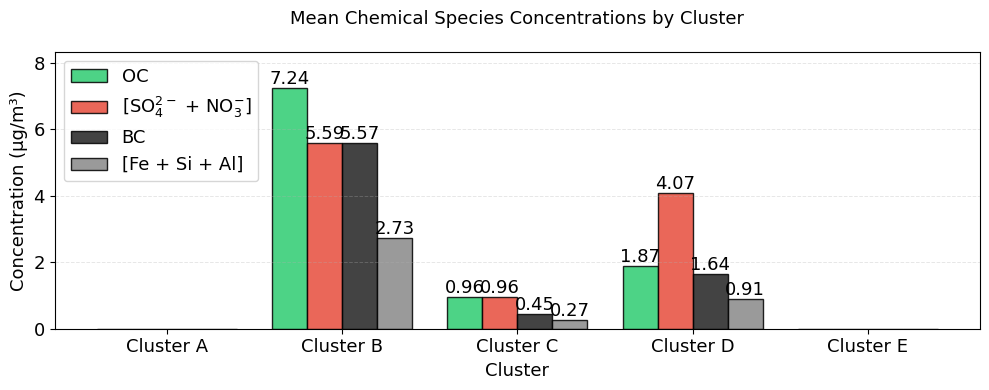

✓ Saved to /content/drive/MyDrive/Data/cluster_plots


In [ ]:
# ==== CELL 14:Chemical species means by cluster (real clusters) ====
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt

base_dir = '/content/drive/MyDrive/Data'
chem_dir = os.path.join(base_dir, 'Chem_data')
out_dir  = os.path.join(base_dir, 'cluster_plots')
os.makedirs(out_dir, exist_ok=True)

# site code -> location (must match Location names in pm25_df_with_clusters.csv)
location_map = {
    'AEAZ':'Abu Dhabi, UAE','AUMN':'Melbourne, Australia','BDDU':'Dhaka, Bangladesh',
    'BIBU':'Bujumbura, Burundi','CAHA':'Halifax, Canada','CASH':'Sherbrooke, Canada',
    'CHTS':'Beijing, China','CLST':'Santiago, Chile','ETAD':'Addis Ababa, Ethiopia',
    'IDBD':'Bandung, Indonesia','ILHA':'Haifa, Israel','ILNZ':'Rehovot, Israel',
    'INDH':'Delhi, India','INKA':'Kanpur, India','KRSE':'Seoul, South Korea',
    'KRUL':'Ulsan, South Korea','MXMC':'Mexico City, Mexico','NGIL':'Ilorin, Nigeria',
    'PRFJ':'Fajardo, Puerto Rico','TWKA':'Kaohsiung, Taiwan','TWTA':'Taipei, Taiwan',
    'USNO':'Norman, USA','USPA':'Pasadena, USA','ZAJB':'Johannesburg, South Africa',
    'ZAPR':'Pretoria, South Africa',
}

parameter_groups = {
    'OC':['OC PM2.5'], 'SO4-2':['Sulfate Ion PM2.5','Sulfate PM2.5'],
    'NO3-':['Nitrate Ion PM2.5','Nitrate PM2.5'], 'BC':['BC PM2.5'],
    'Iron':['Iron PM2.5'], 'Silicon':['Silicon PM2.5'], 'Aluminum':['Aluminum PM2.5'],
}

def to_ug(value, unit):
    if pd.isna(value) or pd.isna(unit): return None
    u = str(unit).lower()
    if 'nanogram' in u or 'ng/m3' in u: return value/1000.0
    if 'microgram' in u or 'ug/m3' in u: return value
    return None

# --- build clusters dict from ACTUAL clustering ---
dfc = pd.read_csv(os.path.join(base_dir, "pm25_df_with_clusters.csv"))
dom = (dfc.groupby(['Location','Cluster']).size().reset_index(name='n')
       .sort_values('n',ascending=False).drop_duplicates('Location'))
clusters = {f'Cluster {chr(65+int(c))}': dom[dom.Cluster==c]['Location'].tolist()
            for c in sorted(dfc['Cluster'].unique())}
print("Clusters:", clusters)

# --- read each chem file, average per location ---
csv_files = [f for f in os.listdir(chem_dir)
             if f.startswith('FilterBased_ChemSpecPM25_') and f.endswith('.csv')]
location_data = {}
for f in csv_files:
    code = f.replace('FilterBased_ChemSpecPM25_','').replace('.csv','').strip()
    loc = location_map.get(code, code)
    try:
        df = pd.read_csv(os.path.join(chem_dir,f), comment='#', skipinitialspace=True, low_memory=False)
    except Exception as e:
        print(f"  skip {f}: {e}"); continue
    if df.empty or 'Parameter_Name' not in df.columns or 'Value' not in df.columns: continue
    if 'Units' not in df.columns: continue
    d = df[['Parameter_Name','Value','Units']].dropna()
    d['Value'] = pd.to_numeric(d['Value'], errors='coerce'); d = d.dropna()
    d['ug'] = d.apply(lambda r: to_ug(r['Value'], r['Units']), axis=1)
    d = d.dropna(subset=['ug'])
    pm = d.groupby('Parameter_Name', as_index=False)['ug'].mean()
    location_data[loc] = dict(zip(pm['Parameter_Name'], pm['ug']))

# --- aggregate to cluster means ---
def first_match(ld, keys):
    for k in keys:
        if k in ld: return ld[k]
    return None

cluster_results = {}
for cname, locs in clusters.items():
    vals = {'OC':[], '[SO4-2 + NO3-]':[], 'BC':[], '[Fe + Si + Al]':[]}
    for loc in locs:
        if loc not in location_data: continue
        ld = location_data[loc]
        oc = first_match(ld, parameter_groups['OC'])
        if oc is not None: vals['OC'].append(oc)
        s = first_match(ld, parameter_groups['SO4-2']); n = first_match(ld, parameter_groups['NO3-'])
        if s is not None or n is not None: vals['[SO4-2 + NO3-]'].append((s or 0)+(n or 0))
        bc = first_match(ld, parameter_groups['BC'])
        if bc is not None: vals['BC'].append(bc)
        fe = first_match(ld, parameter_groups['Iron']); si = first_match(ld, parameter_groups['Silicon']); al = first_match(ld, parameter_groups['Aluminum'])
        if any(v is not None for v in (fe,si,al)): vals['[Fe + Si + Al]'].append((fe or 0)+(si or 0)+(al or 0))
    cluster_results[cname] = {k:(np.mean(v) if v else 0) for k,v in vals.items()}

results_df = pd.DataFrame(cluster_results).T[['OC','[SO4-2 + NO3-]','BC','[Fe + Si + Al]']]
print(results_df.to_string())

# --- plot ---
legend_labels = ['OC', r'[SO$_4^{2-}$ + NO$_3^{-}$]', 'BC', '[Fe + Si + Al]']
colors = ['#2ecc71', '#e74c3c', '#222222', '#888888']; FONTSIZE = 13
fig, ax = plt.subplots(figsize=(10,4)); x = np.arange(len(results_df.index)); width = 0.2
for i,(col,label) in enumerate(zip(results_df.columns, legend_labels)):
    off = width*(i - len(results_df.columns)/2 + 0.5)
    bars = ax.bar(x+off, results_df[col], width, label=label, color=colors[i], alpha=0.85, edgecolor='black')
    for b in bars:
        h = b.get_height()
        if h > 0: ax.text(b.get_x()+b.get_width()/2., h, f'{h:.2f}', ha='center', va='bottom', fontsize=FONTSIZE)
ax.set_xlabel('Cluster', fontsize=FONTSIZE); ax.set_ylabel('Concentration (μg/m³)', fontsize=FONTSIZE)
ax.set_title('Mean Chemical Species Concentrations by Cluster', fontsize=FONTSIZE, pad=20)
ax.set_xticks(x); ax.set_xticklabels(results_df.index, fontsize=FONTSIZE); ax.tick_params(axis='y', labelsize=FONTSIZE)
ax.legend(fontsize=FONTSIZE, loc='upper left'); ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_ylim(bottom=0, top=results_df.values.max()*1.15)
plt.tight_layout()
plt.savefig(os.path.join(out_dir,'cluster_analysis_results.png'), dpi=300, bbox_inches='tight')
plt.show()
results_df.to_csv(os.path.join(out_dir,'cluster_analysis_results.csv'))
print("✓ Saved to", out_dir)

remove A and E + numbers are overlapping

In [ ]:
# ==== CELL 15: Install ====
!pip install -q netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.0 MB/s eta 0:00:00


In [ ]:
# ==== CELL 16:Extract EDGAR fluxes — all years, all species → ONE csv ====
import netCDF4 as nc, numpy as np, pandas as pd, os, glob

base_dir = '/content/drive/MyDrive/Data'
EDGAR_YEARS = {2022: os.path.join(base_dir,'EDGAR_2022'),
               2021: os.path.join(base_dir,'EDGAR_2021'),
               2020: os.path.join(base_dir,'EDGAR_2020')}
out_dir = os.path.join(base_dir, 'edgar_emissions')
os.makedirs(out_dir, exist_ok=True)

locations = {
    'Abu Dhabi, UAE':(24.4539,54.3773,'UAE'),'Santiago, Chile':(-33.4489,-70.6693,'Chile'),
    'Fajardo, Puerto Rico':(18.3384,-65.6563,'Puerto Rico'),'Melbourne, Australia':(-37.8136,144.9631,'Australia'),
    'Addis Ababa, Ethiopia':(9.0192,38.7525,'Ethiopia'),'Bandung, Indonesia':(-6.9175,107.6191,'Indonesia'),
    'Kaohsiung, Taiwan':(22.6273,120.3014,'Taiwan'),'Dhaka, Bangladesh':(23.8041,90.4152,'Bangladesh'),
    'Haifa, Israel':(32.7940,34.9896,'Israel'),'Taipei, Taiwan':(25.0330,121.5654,'Taiwan'),
    'Bujumbura, Burundi':(-3.3614,29.3599,'Burundi'),'Rehovot, Israel':(31.8944,34.8115,'Israel'),
    'Norman, USA':(35.2216,-97.4446,'USA'),'Delhi, India':(28.7041,77.1025,'India'),
    'Halifax, Canada':(44.8857,-63.1005,'Canada'),'Kanpur, India':(26.4499,80.3319,'India'),
    'Seoul, South Korea':(37.5652,126.9774,'South Korea'),'Pasadena, USA':(34.1477,-118.1443,'USA'),
    'Ulsan, South Korea':(35.5377,129.3280,'South Korea'),'Sherbrooke, Canada':(45.4043,-71.8937,'Canada'),
    'Mexico City, Mexico':(19.4326,-99.1332,'Mexico'),'Johannesburg, South Africa':(-26.2056,28.0337,'South Africa'),
    'Beijing, China':(39.9042,116.4074,'China'),'Ilorin, Nigeria':(8.5373,4.5444,'Nigeria'),
    'Pretoria, South Africa':(-25.7566,28.1914,'South Africa'),
}
SPECIES = {'BC':'BC','OC':'OC','CO':'CO','NH3':'NH3','NOx':'NOx','SO2':'SO2'}

def nidx(lat,lon,lats,lons): return int(np.abs(lats-lat).argmin()), int(np.abs(lons-lon).argmin())

records = {}   # (Location, year) -> row dict
for year, folder in EDGAR_YEARS.items():
    if not os.path.isdir(folder):
        print(f"⚠️ {year}: folder missing"); continue
    subs = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder,d))]
    for key in SPECIES:
        m = [d for d in subs if f"_AP_{key}_" in d or f"_AP_{key.upper()}_" in d]
        if not m: print(f"⚠️ {year} {key}: no sub-folder"); continue
        ncs = glob.glob(os.path.join(folder,m[0],"*.nc"))
        if not ncs: print(f"⚠️ {year} {key}: no .nc"); continue
        ds = nc.Dataset(ncs[0],'r')
        lat_g, lon_g = ds.variables['lat'][:], ds.variables['lon'][:]
        fv = [v for v in ds.variables if v not in ('lat','lon','time')][0]
        for name,(lat,lon,country) in locations.items():
            li,oi = nidx(lat,lon,lat_g,lon_g)
            vd = ds.variables[fv]
            val = float(vd[li,oi]) if vd.ndim==2 else (float(vd[0,li,oi]) if vd.ndim==3 else np.nan)
            r = records.setdefault((name,year),
                {'Location':name,'Country':country,'year':year,
                 'Grid_Lat':float(lat_g[li]),'Grid_Lon':float(lon_g[oi])})
            r[f'{key}_flux'] = val
        ds.close()
        print(f"✓ {year} {key}")

df = pd.DataFrame(records.values()).sort_values(['Location','year']).reset_index(drop=True)
out = os.path.join(out_dir, "edgar_emissions_all_years.csv")
df.to_csv(out, index=False)
print(f"\nSaved {df.shape} -> {out}")
print(df.head())

✓ 2022 BC
✓ 2022 OC
✓ 2022 CO
✓ 2022 NH3
✓ 2022 NOx
✓ 2022 SO2
✓ 2021 BC
✓ 2021 OC
✓ 2021 CO
✓ 2021 NH3
✓ 2021 NOx
✓ 2021 SO2
✓ 2020 BC
✓ 2020 OC
✓ 2020 CO
✓ 2020 NH3
✓ 2020 NOx
✓ 2020 SO2

Saved (75, 11) -> /content/drive/MyDrive/Data/edgar_emissions/edgar_emissions_all_years.csv
                Location   Country  year  Grid_Lat  Grid_Lon       BC_flux  \
0         Abu Dhabi, UAE       UAE  2020     24.45     54.35  1.059719e-11   
1         Abu Dhabi, UAE       UAE  2021     24.45     54.35  1.167881e-11   
2         Abu Dhabi, UAE       UAE  2022     24.45     54.35  1.322835e-11   
3  Addis Ababa, Ethiopia  Ethiopia  2020      9.05     38.75  7.691051e-10   
4  Addis Ababa, Ethiopia  Ethiopia  2021      9.05     38.75  7.895028e-10   

        OC_flux       CO_flux      NH3_flux      NOx_flux      SO2_flux  
0  1.127913e-11  1.053550e-09  2.457925e-11  9.583060e-10  1.084531e-10  
1  1.223989e-11  1.156772e-09  2.621934e-11  1.061051e-09  1.204206e-10  
2  1.347545e-11  1.293209e-

In [ ]:
# ==== CELL 17:Build location_year_species_mean.csv from Chem_data (YEARLY) ====
import pandas as pd, numpy as np, os
BASE = '/content/drive/MyDrive/Data'
chem_dir = os.path.join(BASE, 'Chem_data')

location_map = {
    'AEAZ':'Abu Dhabi, UAE','AUMN':'Melbourne, Australia','BDDU':'Dhaka, Bangladesh',
    'BIBU':'Bujumbura, Burundi','CAHA':'Halifax, Canada','CASH':'Sherbrooke, Canada',
    'CHTS':'Beijing, China','CLST':'Santiago, Chile','ETAD':'Addis Ababa, Ethiopia',
    'IDBD':'Bandung, Indonesia','ILHA':'Haifa, Israel','ILNZ':'Rehovot, Israel',
    'INDH':'Delhi, India','INKA':'Kanpur, India','KRSE':'Seoul, South Korea',
    'KRUL':'Ulsan, South Korea','MXMC':'Mexico City, Mexico','NGIL':'Ilorin, Nigeria',
    'PRFJ':'Fajardo, Puerto Rico','TWKA':'Kaohsiung, Taiwan','TWTA':'Taipei, Taiwan',
    'USNO':'Norman, USA','USPA':'Pasadena, USA','ZAJB':'Johannesburg, South Africa',
    'ZAPR':'Pretoria, South Africa',
}
def to_ug(v,u):
    if pd.isna(v) or pd.isna(u): return None
    u=str(u).lower()
    if 'nanogram' in u or 'ng/m3' in u: return v/1000.0
    if 'microgram' in u or 'ug/m3' in u: return v
    return None

frames=[]
for f in os.listdir(chem_dir):
    if not (f.startswith('FilterBased_ChemSpecPM25_') and f.endswith('.csv')): continue
    code=f.replace('FilterBased_ChemSpecPM25_','').replace('.csv','').strip()
    loc=location_map.get(code, code)
    try:
        df=pd.read_csv(os.path.join(chem_dir,f), comment='#', skipinitialspace=True, low_memory=False)
    except Exception as e: print(f"skip {f}: {e}"); continue
    df.columns=df.columns.str.strip()
    ycol=next((c for c in ['End_Year_local','End_Year','Start_Year_local','Start_Year'] if c in df.columns), None)
    if ycol is None or not {'Parameter_Name','Value','Units'}.issubset(df.columns):
        print(f"skip {f}: missing cols"); continue
    d=df[['Parameter_Name','Value','Units',ycol]].copy()
    d['Value']=pd.to_numeric(d['Value'],errors='coerce')
    d['year']=pd.to_numeric(d[ycol],errors='coerce')
    d=d.dropna(subset=['Value','year'])
    d['ug']=d.apply(lambda r: to_ug(r['Value'],r['Units']), axis=1)
    d=d.dropna(subset=['ug']); d['year']=d['year'].astype(int)
    m=d.groupby(['year','Parameter_Name'])['ug'].mean().reset_index()
    piv=m.pivot(index='year',columns='Parameter_Name',values='ug')
    piv['Location']=loc
    frames.append(piv.reset_index())

out=pd.concat(frames, ignore_index=True)
print("Raw species columns:", [c for c in out.columns if c not in ('year','Location')])

# composites (uses partial name matching so 'Sulfate Ion'/'Sulfate Ion PM2.5' both work)
def col(df, *keys):
    s=pd.Series(0.0, index=df.index)
    for k in keys:
        hit=[c for c in df.columns if c.lower().startswith(k.lower())]
        if hit: s=s+df[hit[0]].fillna(0)
    return s
out['SIA']    = col(out,'Sulfate','Nitrate','Ammonium')   # ion forms
out['CARBON'] = col(out,'OC','BC')
out['DUST']   = col(out,'Iron','Silicon','Aluminum','Calcium')
out['METAL']  = col(out,'Zinc','Vanadium','Nickel','Arsenic','Cadmium','Lead')

keep=out[['Location','year','SIA','CARBON','DUST','METAL']]
path=os.path.join(BASE,'location_year_species_mean.csv')
keep.to_csv(path, index=False)
print(f"Saved {keep.shape} -> {path}")
print(keep.head())

Raw species columns: ['Aluminum PM2.5', 'Ammonium Ion PM2.5', 'Antimony PM2.5', 'Arsenic PM2.5', 'BC PM2.5', 'Barium PM2.5', 'Bromide Ion PM2.5', 'Cadmium PM2.5', 'Calcium Ion PM2.5', 'Calcium PM2.5', 'Cerium PM2.5', 'Chlorine PM2.5', 'Chromium PM2.5', 'Cobalt PM2.5', 'Copper PM2.5', 'EC PM2.5', 'Equivalent BC PM2.5', 'Filter PM2.5 mass', 'Iron PM2.5', 'Lead PM2.5', 'Lithium PM2.5', 'Magnesium Ion PM2.5', 'Magnesium PM2.5', 'Manganese PM2.5', 'Nickel PM2.5', 'Nitrate Ion PM2.5', 'Nitrite Ion PM2.5', 'OC PM2.5', 'Phosphate Ion PM2.5', 'Phosphorus PM2.5', 'Potassium Ion PM2.5', 'Potassium PM2.5', 'Rubidium PM2.5', 'Selenium PM2.5', 'Silicon PM2.5', 'Sodium Ion PM2.5', 'Sodium PM2.5', 'Strontium PM2.5', 'Sulfate Ion PM2.5', 'Sulfur PM2.5', 'Tin PM2.5', 'Titanium PM2.5', 'Vanadium PM2.5', 'Zinc PM2.5', 'OM PM2.5']
Saved (130, 6) -> /content/drive/MyDrive/Data/location_year_species_mean.csv
Parameter_Name         Location  year       SIA     CARBON      DUST     METAL
0               Ilorin

Step 1: optical
  optical yearly rows: 78
Step 2: meteorology
  met yearly rows: 125
Step 3: EDGAR
  emission rows: 75
Step 4: chemistry
Step 5: merge
  master shape (78, 25), locations=25, years=[np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0)]
Step 6: t-SNE


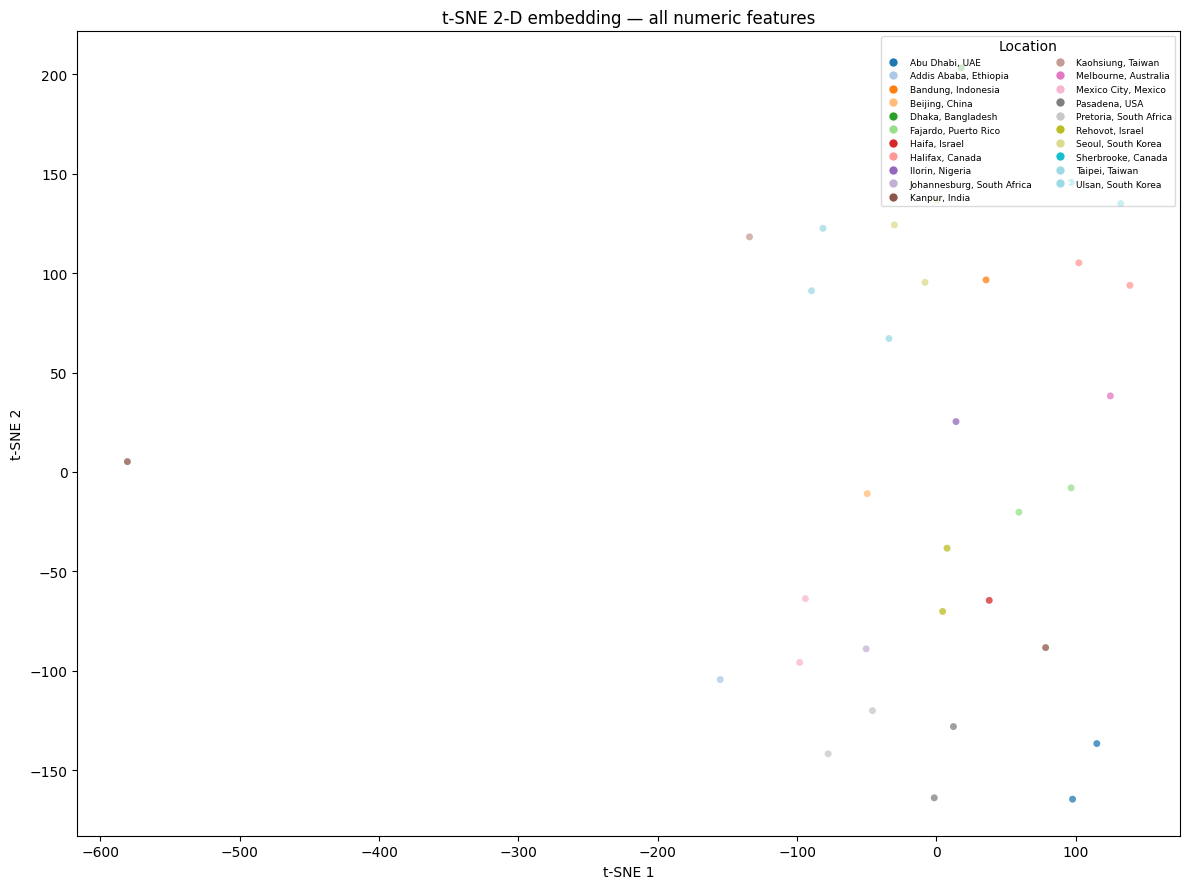

  t-SNE on 33 rows


In [ ]:
# ==== CELL 18: Build master dataset (optical + met + EDGAR + chem) + t-SNE ====
import glob, warnings, numpy as np, pandas as pd, os
import matplotlib.pyplot as plt, matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
warnings.filterwarnings("ignore")

BASE    = '/content/drive/MyDrive/Data'
OUT_DIR = os.path.join(BASE, 'yearly_outputs'); os.makedirs(OUT_DIR, exist_ok=True)
MET_DIR      = os.path.join(BASE, 'nasa_data_yearly')
OPTICAL_FILE = os.path.join(BASE, 'pm25_df_with_clusters.csv')
CHEM_FILE    = os.path.join(BASE, 'location_wise_all_species_mean.csv')
EDGAR_FILE   = os.path.join(BASE, 'edgar_emissions', 'edgar_emissions_all_years.csv')

# --- 1. OPTICAL: yearly mean per location ---
print("Step 1: optical")
opt_raw = pd.read_csv(OPTICAL_FILE, low_memory=False)
date_col = next((c for c in ["Sampling End Date","Sampling Start Date","Sampling Mid Date"]
                 if c in opt_raw.columns), None)
if date_col is None: raise ValueError("No date column in optical file")
want = ["Location",date_col,"b_abs_lambda","MAC_lambda","AAE@400_650","AAE@650_900","Cluster"]
miss = [c for c in want if c not in opt_raw.columns]
if miss: raise ValueError(f"Missing optical cols: {miss}")
opt = opt_raw[want].copy()
opt[date_col] = pd.to_datetime(opt[date_col], errors="coerce")
opt["year"] = opt[date_col].dt.year
opt["Location"] = opt["Location"].str.strip()
opt.drop(columns=[date_col], inplace=True)
opt_yr = opt.groupby(["Location","year"])[["b_abs_lambda","MAC_lambda","AAE@400_650","AAE@650_900"]].mean().reset_index()
print(f"  optical yearly rows: {len(opt_yr)}")

# --- 2. METEOROLOGY: NASA POWER per-city CSVs (all years, ANN) ---
print("Step 2: meteorology")
def read_nasa_power_csv(p):
    hl=None
    with open(p,"r",encoding="utf-8",errors="replace") as fh:
        for i,line in enumerate(fh):
            if line.strip()=="-END HEADER-": hl=i+1; break
    if hl is None: raise ValueError(f"No -END HEADER- in {p}")
    df=pd.read_csv(p, skiprows=hl, header=0, low_memory=False)
    df.columns=df.columns.str.strip()
    df.replace(-999,np.nan,inplace=True); df.replace(-999.0,np.nan,inplace=True)
    months=["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]
    if "ANN" in df.columns:
        s=df[["PARAMETER","YEAR","ANN"]].rename(columns={"ANN":"value"})
    else:
        pm=[m for m in months if m in df.columns]; df["value"]=df[pm].mean(axis=1)
        s=df[["PARAMETER","YEAR","value"]].copy()
    s["YEAR"]=pd.to_numeric(s["YEAR"],errors="coerce").astype("Int64")
    s=s.dropna(subset=["YEAR","PARAMETER"])
    piv=s.pivot_table(index="YEAR",columns="PARAMETER",values="value",aggfunc="mean")
    piv.index.name="year"; piv.columns.name=None
    return piv.reset_index()

met_frames=[]
for p in sorted(glob.glob(os.path.join(MET_DIR,"*.csv"))):
    try:
        t=read_nasa_power_csv(p); t["Location"]=os.path.splitext(os.path.basename(p))[0].strip()
        met_frames.append(t)
    except Exception as e: print(f"  WARN {p}: {e}")
if not met_frames: raise FileNotFoundError(f"No CSVs in {MET_DIR}")
met_raw=pd.concat(met_frames, ignore_index=True)
met_raw["Location"]=met_raw["Location"].str.strip(); met_raw["year"]=met_raw["year"].astype(int)
met_num=[c for c in met_raw.columns if c not in ["Location","year"] and pd.api.types.is_numeric_dtype(met_raw[c])]
met_yr=met_raw.groupby(["Location","year"])[met_num].mean().reset_index()
met_yr.rename(columns={c:f"met_{c}" for c in met_num}, inplace=True)
print(f"  met yearly rows: {len(met_yr)}")

# --- 3. EDGAR emissions (single combined file, yearly) ---
print("Step 3: EDGAR")
emissions=pd.read_csv(EDGAR_FILE)
emissions["Location"]=emissions["Location"].str.strip()
em_cols=['BC_flux','OC_flux','CO_flux','NH3_flux','NOx_flux','SO2_flux']
emissions=emissions[["Location","year"]+[c for c in em_cols if c in emissions.columns]]
print(f"  emission rows: {len(emissions)}")

# --- 4. CHEMICAL (yearly) ---
print("Step 4: chemistry")
chem_yr = pd.read_csv(os.path.join(BASE,'location_year_species_mean.csv'))
chem_yr['Location']=chem_yr['Location'].str.strip()

# --- 5. MERGE ---
print("Step 5: merge")
master = opt_yr.copy()
master = master.merge(met_yr,    on=["Location","year"], how="left")
master = master.merge(emissions, on=["Location","year"], how="left")
master = master.merge(chem_yr,   on=["Location","year"], how="left")

# restrict to 2020–2024
master = master[master["year"].between(2020, 2024)].reset_index(drop=True)

out_csv = os.path.join(OUT_DIR, "master_dataset.csv")
master.to_csv(out_csv, index=False)
print(f"  master shape {master.shape}, locations={master['Location'].nunique()}, years={sorted(master['year'].dropna().unique())}")

# --- 6. t-SNE 2D ---
print("Step 6: t-SNE")
exclude={"Location","year","b_abs_lambda","Cluster"}
feat=[c for c in master.columns if c not in exclude and pd.api.types.is_numeric_dtype(master[c])]
tdf=master[["Location","b_abs_lambda"]+feat].dropna()
if len(tdf) >= 5:
    Xs=StandardScaler().fit_transform(tdf[feat].values)
    perp=min(30, max(2, len(tdf)//3))
    X2=TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000).fit_transform(Xs)
    locs=tdf["Location"].values; uniq=sorted(set(locs))
    cmap=cm.get_cmap("tab20", len(uniq)); lc={l:cmap(i) for i,l in enumerate(uniq)}
    fig,ax=plt.subplots(figsize=(12,9))
    ax.scatter(X2[:,0],X2[:,1],c=[lc[l] for l in locs],s=25,alpha=0.75,edgecolors="none")
    h=[plt.Line2D([0],[0],marker="o",color="w",markerfacecolor=lc[l],markersize=7,label=l) for l in uniq]
    ax.legend(handles=h, fontsize=6.5, loc="upper right", ncol=2, framealpha=0.7, title="Location")
    ax.set_title("t-SNE 2-D embedding — all numeric features")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2"); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR,"tsne_2d.png"), dpi=180, bbox_inches="tight"); plt.show()
    print(f"  t-SNE on {len(tdf)} rows")
else:
    print(f"  ⚠ only {len(tdf)} complete rows — t-SNE skipped")

Loaded (78, 25), locations=25, years=[np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0)]
Emission NaNs 252 -> 30 (filled 222)
Predictors 19 | optical 4
  done b_abs_lambda
  done MAC_lambda
  done AAE@400_650
  done AAE@650_900


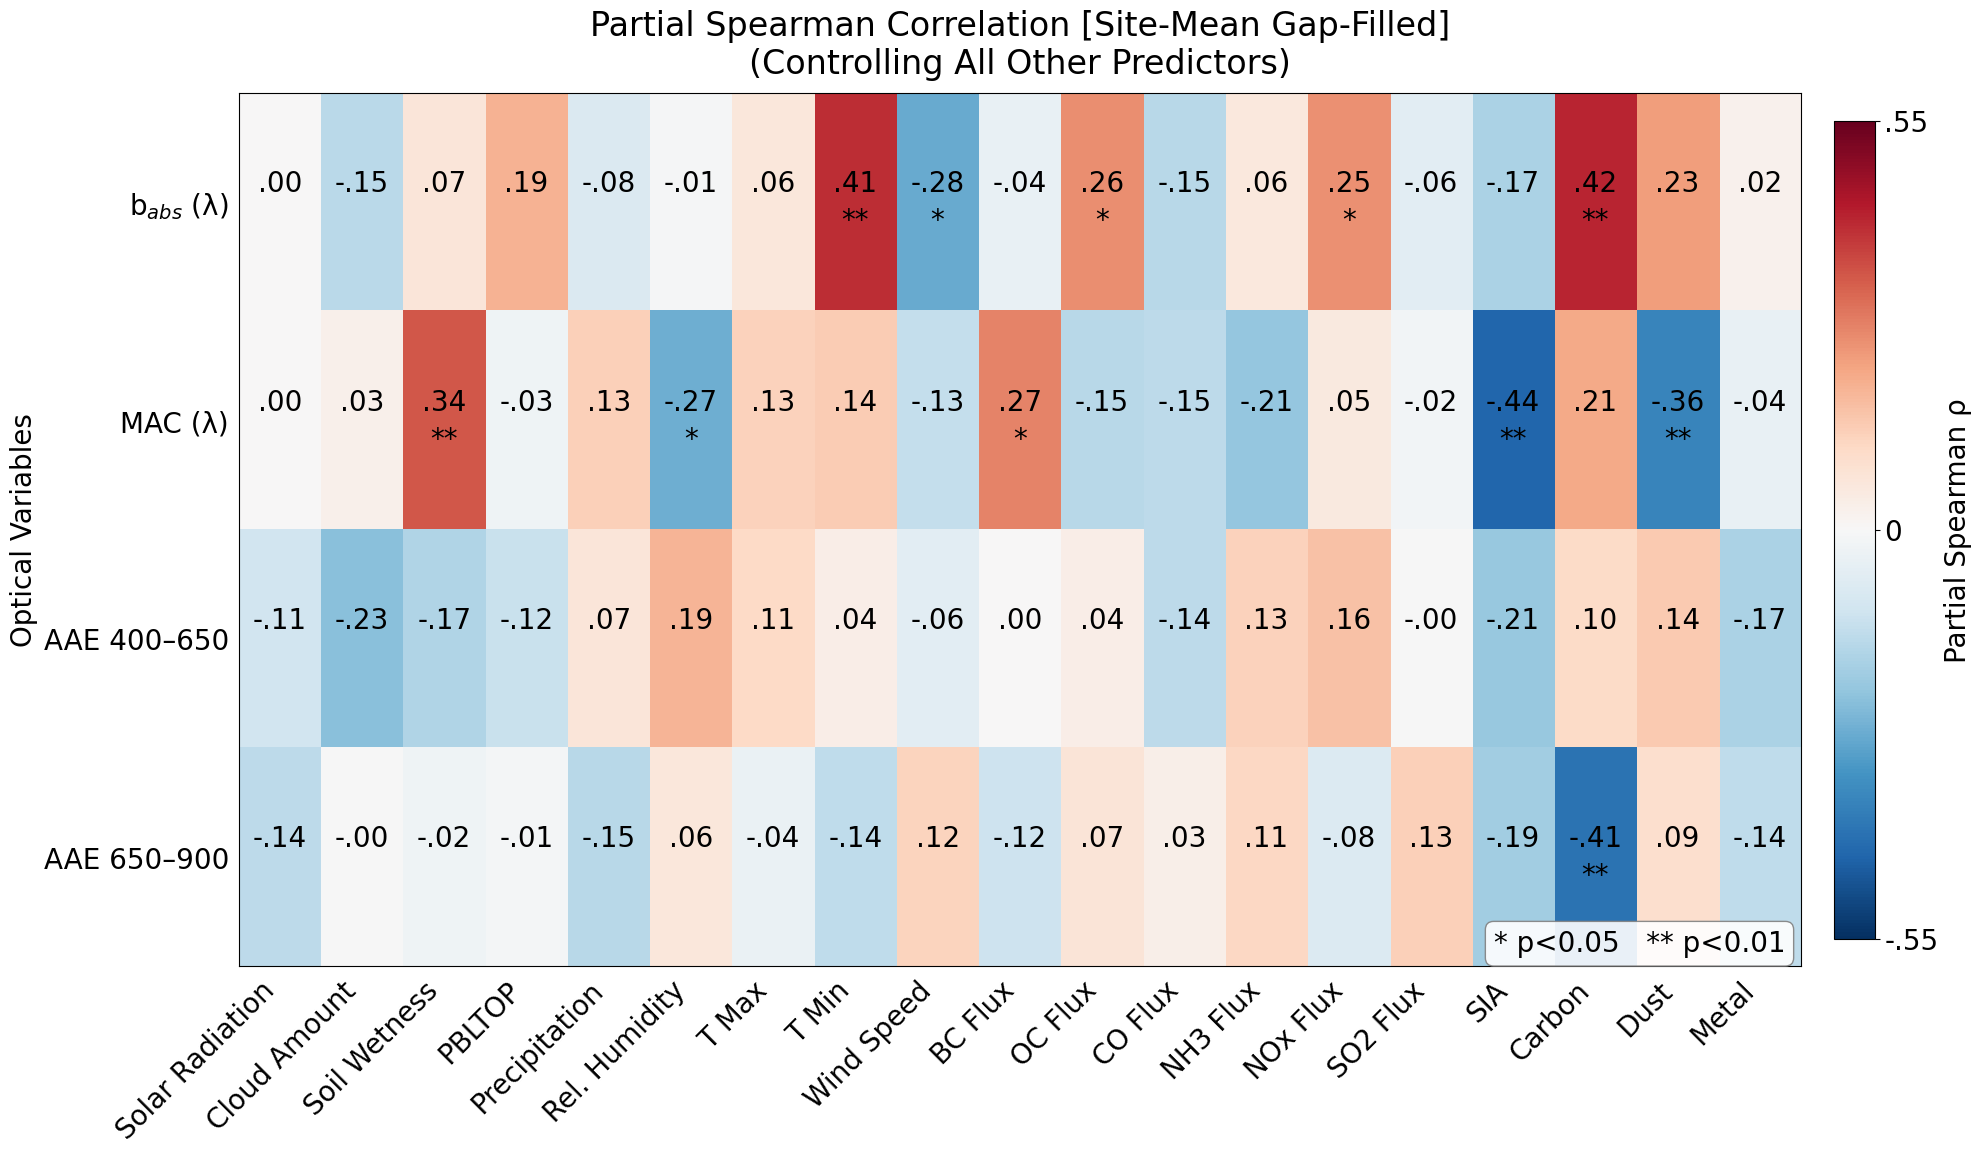

Saved heatmap -> /content/drive/MyDrive/Data/yearly_outputs


In [ ]:
# ==== CELL 19: Partial Spearman correlations (gap-filled emissions) + heatmap ====
import math, warnings, numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
from itertools import permutations as iter_permutations
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from sklearn.linear_model import LinearRegression
warnings.filterwarnings("ignore")

BASE    = '/content/drive/MyDrive/Data'
OUT_DIR = os.path.join(BASE, 'yearly_outputs')
MASTER_CSV = os.path.join(OUT_DIR, "master_dataset.csv")
MAX_PERM, EXACT_THRESHOLD, RANDOM_SEED = 10_000, 40_320, 42
SIG1_ALPHA, SIG2_ALPHA, FONT_SIZE = 0.05, 0.01, 20

OPTICAL_ROWS = ["b_abs_lambda","MAC_lambda","AAE@400_650","AAE@650_900"]
OPTICAL_LABELS = {"b_abs_lambda":r"b$_{abs}$ (λ)","MAC_lambda":r"MAC (λ)",
                  "AAE@400_650":"AAE 400–650","AAE@650_900":"AAE 650–900"}
MET_COLS = {"met_ALLSKY_SFC_SW_DWN":"Solar Radiation","met_CLOUD_AMT":"Cloud Amount",
            "met_GWETPROF":"Soil Wetness","met_PBLTOP":"PBLTOP","met_PRECTOTCORR_SUM":"Precipitation",
            "met_RH2M":"Rel. Humidity","met_T2M_MAX":"T Max","met_T2M_MIN":"T Min","met_WS2M":"Wind Speed"}
EM_COLS = {"BC_flux":"BC Flux","OC_flux":"OC Flux","CO_flux":"CO Flux",
           "NH3_flux":"NH3 Flux","NOx_flux":"NOx Flux","SO2_flux":"SO2 Flux"}
CHEM_COLS = {"SIA":"SIA","CARBON":"Carbon","DUST":"Dust","METAL":"Metal"}
EM_KEYS = list(EM_COLS.keys())

master = pd.read_csv(MASTER_CSV, low_memory=False)
print(f"Loaded {master.shape}, locations={master['Location'].nunique()}, years={sorted(master['year'].dropna().unique())}")

# --- gap-fill emissions with site-level temporal mean (fills 2023/24) ---
df = master.copy(); fill_log=[]
before = master[EM_KEYS].isna().sum().sum()
for loc, grp in df.groupby("Location"):
    miss = grp[grp[EM_KEYS[0]].isna()]
    if miss.empty: continue
    for em in EM_KEYS:
        known = grp.loc[~grp[em].isna(), em]; n=len(known)
        fill = float(known.mean()) if n>0 else np.nan
        for idx in miss.index:
            df.at[idx, em] = fill
            fill_log.append({"Location":loc,"year":int(df.at[idx,"year"]),"variable":em,"filled":fill,"n_src":n})
after = df[EM_KEYS].isna().sum().sum()
print(f"Emission NaNs {before} -> {after} (filled {before-after})")
df.to_csv(os.path.join(OUT_DIR,"site_mean_master_dataset.csv"), index=False)
pd.DataFrame(fill_log).to_csv(os.path.join(OUT_DIR,"site_mean_emission_report.csv"), index=False)

met_p={k:v for k,v in MET_COLS.items() if k in df.columns}
em_p ={k:v for k,v in EM_COLS.items()  if k in df.columns}
chem_p={k:v for k,v in CHEM_COLS.items() if k in df.columns}
all_pred=list(met_p)+list(em_p)+list(chem_p)
all_label=list(met_p.values())+list(em_p.values())+list(chem_p.values())
n_x,n_y=len(all_pred),len(OPTICAL_ROWS)
print(f"Predictors {n_x} | optical {n_y}")

def partial_spearman(d,y,x,cov,max_perm=MAX_PERM,exact=EXACT_THRESHOLD,seed=RANDOM_SEED):
    sub=d[[y,x]+cov].dropna(); n=len(sub)
    if n<5: return np.nan,np.nan,n,"n/a",0
    r=sub.rank(method="average"); Y,X,Z=r[y].values,r[x].values,r[cov].values
    if Z.shape[1]==0: resY,resX=Y-Y.mean(),X-X.mean()
    else:
        reg=LinearRegression(); reg.fit(Z,Y); resY=Y-reg.predict(Z); reg.fit(Z,X); resX=X-reg.predict(Z)
    obs=np.corrcoef(resY,resX)[0,1]
    if math.factorial(n)<=exact:
        mode="exact"; null=np.array([np.corrcoef(resY,np.array(p))[0,1] for p in iter_permutations(resX)]); ne=len(null)
    else:
        mode="mc"; rng=np.random.default_rng(seed); null=np.empty(max_perm)
        for k in range(max_perm): null[k]=np.corrcoef(resY,rng.permutation(resX))[0,1]
        ne=max_perm
    p=(int(np.sum(np.abs(null)>=np.abs(obs)))+1)/(ne+1)
    return obs,p,n,mode,ne

rho_m=np.full((n_y,n_x),np.nan); p_m=np.full((n_y,n_x),np.nan); rows=[]
for i,oc in enumerate(OPTICAL_ROWS):
    if oc not in df.columns: continue
    for j,xc in enumerate(all_pred):
        cov=[c for c in all_pred if c!=xc and c in df.columns]
        rho,p,n,mode,ne=partial_spearman(df,oc,xc,cov)
        rho_m[i,j]=rho; p_m[i,j]=p
        rows.append({"optical":oc,"predictor":xc,"label":all_label[j],"partial_rho":rho,
                     "p_value":p,"p_method":mode,"n_perm":ne,"n_obs":n})
    print(f"  done {oc}")
results_df=pd.DataFrame(rows); results_df.to_csv(os.path.join(OUT_DIR,"site_mean_partial_results.csv"), index=False)

# --- heatmap ---
plt.rcParams.update({"font.size":FONT_SIZE})
fig,ax=plt.subplots(figsize=(max(14,n_x*1.05), n_y*2.2+3.5))
im=ax.imshow(rho_m, cmap=plt.cm.RdBu_r, norm=TwoSlopeNorm(vmin=-0.55,vcenter=0,vmax=0.55), aspect="auto")
def fmt(v):
    s=f"{abs(v):.2f}"; s=s[1:] if s.startswith("0.") else s
    return f"-{s}" if v<0 else s
for i in range(n_y):
    for j in range(n_x):
        rho,p=rho_m[i,j],p_m[i,j]
        if np.isnan(rho): ax.text(j,i,"n/a",ha="center",va="center",color="gray"); continue
        sig="**" if p<SIG2_ALPHA else ("*" if p<SIG1_ALPHA else "")
        ax.text(j,i,f"{fmt(rho)}\n{sig}",ha="center",va="center",
                color="white" if abs(rho)>0.55 else "black", multialignment="center", linespacing=1.4)
ax.set_xticks(range(n_x)); ax.set_xticklabels(all_label, rotation=45, ha="right")
ax.set_yticks(range(n_y)); ax.set_yticklabels([OPTICAL_LABELS.get(c,c) for c in OPTICAL_ROWS])
ax.set_ylabel("Optical Variables"); ax.tick_params(left=False, bottom=False)
cbar=fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02); cbar.set_label("Partial Spearman ρ")
cbar.set_ticks([-0.55,0,0.55]); cbar.set_ticklabels(["-.55","0",".55"])
ax.set_title("Partial Spearman Correlation [Site-Mean Gap-Filled]\n(Controlling All Other Predictors)", pad=14)
ax.text(0.99,0.01,f"* p<{SIG1_ALPHA}   ** p<{SIG2_ALPHA}", transform=ax.transAxes, ha="right", va="bottom",
        bbox=dict(boxstyle="round,pad=0.3",facecolor="white",edgecolor="gray",alpha=0.9))
plt.subplots_adjust(bottom=0.20, top=0.91, left=0.11, right=0.93)
plt.savefig(os.path.join(OUT_DIR,"site_mean_partial_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved heatmap ->", OUT_DIR)

In [ ]:
# ==== CELL 20: APCA train/test + IDW prediction (logic unchanged) ====

import os
BASE = '/content/drive/MyDrive/Data'
OUT_DIR = os.path.join(BASE, 'apca_outputs')
os.makedirs(OUT_DIR, exist_ok=True)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt          # NOTE: no matplotlib.use('Agg') -> plots show inline
from matplotlib import rcParams
from scipy.stats import gmean
from scipy import linalg
from scipy.spatial.distance import cdist
from sklearn.preprocessing import MinMaxScaler
import warnings; warnings.filterwarnings('ignore')

IDW_POWER, EPS = 1, 1e-10

rcParams.update({'font.family':'serif','font.serif':['DejaVu Serif','Georgia'],
    'font.size':10,'axes.titlesize':11,'axes.titleweight':'bold','axes.labelsize':10,
    'axes.linewidth':0.8,'axes.spines.top':False,'axes.spines.right':False,
    'legend.fontsize':9,'figure.dpi':150,'savefig.dpi':150,'savefig.bbox':'tight',
    'pdf.fonttype':42,'ps.fonttype':42})

PALETTE = ['#FFD700', 'red', 'blue', 'green', 'magenta', 'cyan', 'orange', 'purple','#878787','#C51B7D','#4393C3']
CLUSTER_COLORS = {0:'#FFD700',1:'red',2:'blue',3:'green'}
CLUSTER_LABELS = {0:'A',1:'B',2:'C',3:'D'}
TEST_SITES = ['Delhi, India','Santiago, Chile','Johannesburg, South Africa','Melbourne, Australia','Seoul, South Korea']

class AbsolutePCA:
    def __init__(self, n_components=None, rotation='varimax'):
        self.n_components=n_components; self.rotation=rotation
    def _estimate_weights(self, X):
        n,m=X.shape; W=np.zeros_like(X,dtype=float); k1,k2=1,0.05
        self._k1,self._k2=k1,k2; self._Cj=[]
        for j in range(m):
            col=X[:,j]; pos=col[col>0]
            C_j=np.percentile(pos,5) if len(pos)>0 else 1e-6; self._Cj.append(C_j)
            for i in range(n):
                v=k1*C_j**2+C_j*col[i]+(k2*col[i])**2
                W[i,j]=1.0/np.sqrt(v) if v>0 else 1.0
        return W
    def _compute_row_col_weights(self, W):
        Ws=np.where(W>0,W,1e-10); ga=gmean(Ws.flatten())
        return gmean(Ws,axis=1)/np.sqrt(ga), gmean(Ws,axis=0)/np.sqrt(ga)
    def _varimax_rotation(self, L):
        nf,ncp=L.shape; R=np.eye(ncp)
        for _ in range(1000):
            rot=L@R
            u,_,vh=linalg.svd(L.T@(rot**3-(1/nf)*rot@np.diag(np.sum(rot**2,axis=0))))
            Rn=u@vh
            if np.allclose(R,Rn,atol=1e-6): break
            R=Rn
        return L@R, R
    def _determine_n_components(self, ev):
        ne=len(ev); chi=np.array([np.sqrt(np.sum(ev[j:])) for j in range(1,ne)])
        elbow=np.argmax(np.abs(np.diff(chi,n=2)))+2 if len(chi)>2 else min(3,ne-1)
        return max(2,min(elbow,min(8,ne-1)))
    def fit(self, X, feature_names=None):
        X=np.asarray(X,dtype=float); ns,nf=X.shape
        self.feature_names_=feature_names or [f'F{i}' for i in range(nf)]
        self.W_=self._estimate_weights(X); Xw,Yw=self._compute_row_col_weights(self.W_)
        self.X_weights_,self.Y_weights_=Xw,Yw
        Ws=np.where(self.W_>0,self.W_,1e-10)
        self.gmean_all_=gmean(Ws.flatten()); self.gmean_rows_=gmean(Ws,axis=1); self.gmean_cols_=gmean(Ws,axis=0)
        self.Z_=np.diag(Xw)@X@np.diag(Yw); n,m=X.shape
        self.R_matrix_=(self.Z_.T@self.Z_)/(n*m)
        ev,evec=np.linalg.eigh(self.R_matrix_); idx=ev.argsort()[::-1]; ev,evec=ev[idx],evec[:,idx]
        self.eigenvalues_=ev; self.eigenvectors_=evec
        self.chi_=np.array([np.sqrt(np.sum(ev[j:])) for j in range(1,len(ev))])
        if self.n_components is None: self.n_components=self._determine_n_components(ev)
        Q=evec[:,:self.n_components]; ret=ev[:self.n_components]; self.Q_unrotated_=Q.copy()
        if self.rotation=='varimax' and self.n_components>1:
            Qr,Rm=self._varimax_rotation(Q); self.rotation_matrix_=Rm
        else:
            Qr,self.rotation_matrix_=Q,np.eye(self.n_components)
        self.Q_rotated_=Qr; L=Qr/Yw[:,np.newaxis]; nfac=np.sum(np.abs(L),axis=0)
        self.normalization_factors_=nfac; self.components_=(L/nfac).T
        self.scores_=(X@np.diag(Yw)@Qr)*nfac; self.explained_variance_ratio_=ret/np.sum(ev)
        return self
    def transform(self, Xs):
        X=np.asarray(Xs,dtype=float); return (X@np.diag(self.Y_weights_)@self.Q_rotated_)*self.normalization_factors_

# --- load data: everything comes from master_dataset.csv ---
print("Loading data...")
master = pd.read_csv(os.path.join(BASE,'yearly_outputs','master_dataset.csv'))
master['Location'] = master['Location'].str.strip()

pm25_df = pd.read_csv(os.path.join(BASE,'pm25_df_with_clusters.csv'))  # for b_abs + Cluster

location_cluster_map = (pm25_df.groupby('Location')['Cluster']
                        .agg(lambda x: x.value_counts().idxmax()).astype(int))

chem_params=['SIA','CARBON','DUST','METAL']
met_params=['met_ALLSKY_SFC_SW_DWN','met_CLOUD_AMT','met_GWETPROF','met_PBLTOP',
            'met_PRECTOTCORR_SUM','met_RH2M','met_T2M_MAX','met_T2M_MIN','met_WS2M']
emission_params=['CO_flux','NH3_flux','NOx_flux','SO2_flux','BC_flux','OC_flux']
ALL_PARAMS=chem_params+met_params+emission_params

GROUP_COLORS={}
for p in chem_params: GROUP_COLORS[p]='#D6604D'
for p in met_params: GROUP_COLORS[p]='#4DAC26'
for p in emission_params: GROUP_COLORS[p]='#8073AC'
boundaries=[len(chem_params), len(chem_params)+len(met_params)]

# per-location mean across years -> one row per site (predictors only)
unified_df = master.groupby('Location')[ALL_PARAMS].mean()

available_test=[s for s in TEST_SITES if s in unified_df.index]
missing_test=[s for s in TEST_SITES if s not in unified_df.index]
if missing_test: print(f"  ⚠ Test sites missing: {missing_test}")
train_df=unified_df.drop(index=available_test, errors='ignore')[ALL_PARAMS]
test_df=unified_df.loc[available_test, ALL_PARAMS]
print(f"Train {len(train_df)} | Test {len(test_df)} -> {available_test}")

train_clean, test_clean = train_df.copy(), test_df.copy()
if train_clean.isna().sum().sum()>0: train_clean=train_clean.fillna(train_clean.median())
if test_clean.isna().sum().sum()>0:  test_clean =test_clean.fillna(train_df.median())

scaler=MinMaxScaler()
train_scaled=pd.DataFrame(scaler.fit_transform(train_clean),columns=ALL_PARAMS,index=train_df.index)
test_scaled =pd.DataFrame(scaler.transform(test_clean),columns=ALL_PARAMS,index=test_df.index)

apca=AbsolutePCA(n_components=None,rotation='varimax')
apca.fit(train_scaled.values, feature_names=ALL_PARAMS)
comp_names=[f'Comp_{i+1}' for i in range(apca.n_components)]; nc=apca.n_components
print(f"APCA components={nc}, variance={np.sum(apca.explained_variance_ratio_):.1%}")

train_scores=pd.DataFrame(apca.scores_,columns=comp_names,index=train_scaled.index)
train_scores['Cluster']=train_scores.index.map(location_cluster_map)
score_cols_all=comp_names
centroids=(train_scores.dropna(subset=['Cluster']).groupby('Cluster')[score_cols_all].mean())
cluster_counts=train_scores.dropna(subset=['Cluster']).groupby('Cluster').size()

train_locs=set(train_scaled.index)
pm25_train=pm25_df[pm25_df['Location'].isin(train_locs)]
train_abs_map=pm25_train.groupby('Location')['b_abs_lambda'].mean()
abs_cluster_stats=(pm25_train.groupby('Cluster')['b_abs_lambda']
                   .agg(['count','mean','std','median',lambda x:x.quantile(0.25),lambda x:x.quantile(0.75)])
                   .rename(columns={'<lambda_0>':'Q25','<lambda_1>':'Q75'}))
abs_cluster_stats.columns=['n','mean','std','median','Q25','Q75']

test_scores=pd.DataFrame(apca.transform(test_scaled.values),columns=comp_names,index=test_scaled.index)

# --- Two-point IDW ---
test_xy=test_scores[score_cols_all].values; cent_xy=centroids[score_cols_all].values; train_xy=train_scores[score_cols_all].values
dists_to_cent=cdist(test_xy,cent_xy); dists_to_train=cdist(test_xy,train_xy)
nearest_cent_idx=dists_to_cent.argmin(axis=1); nearest_train_idx=dists_to_train.argmin(axis=1)
train_locs_ordered=list(train_scores.index)
train_abs_arr=np.array([train_abs_map.get(l,np.nan) for l in train_locs_ordered])

pred_b_abs,pred_clust_int,pred_cluster,d31_list,d32_list,nearest_pt_list=[],[],[],[],[],[]
for i,loc in enumerate(test_scores.index):
    ci=nearest_cent_idx[i]; cid=int(centroids.index[ci]); d31=max(dists_to_cent[i,ci],EPS)
    z1=abs_cluster_stats.loc[cid,'mean'] if cid in abs_cluster_stats.index else np.nan; w1=1.0/(d31**IDW_POWER)
    ti=nearest_train_idx[i]; d32=max(dists_to_train[i,ti],EPS); z2=train_abs_arr[ti]; w2=1.0/(d32**IDW_POWER)
    if np.isnan(z1) and np.isnan(z2): z3=np.nan
    elif np.isnan(z1): z3=z2
    elif np.isnan(z2): z3=z1
    else: z3=(w1*z1+w2*z2)/(w1+w2)
    pred_b_abs.append(z3); pred_clust_int.append(cid); pred_cluster.append(CLUSTER_LABELS.get(cid,str(cid)))
    d31_list.append(dists_to_cent[i,ci]); d32_list.append(dists_to_train[i,ti]); nearest_pt_list.append(train_locs_ordered[ti])

test_scores['Predicted_Cluster']=pred_cluster; test_scores['Nearest_Train_Site']=nearest_pt_list
test_scores['d_centroid']=d31_list; test_scores['d_nearest_pt']=d32_list
w1_arr=1.0/(np.array(d31_list)+EPS)**IDW_POWER; w2_arr=1.0/(np.array(d32_list)+EPS)**IDW_POWER
test_scores['frac_w_centroid']=w1_arr/(w1_arr+w2_arr); test_scores['frac_w_nearestpt']=w2_arr/(w1_arr+w2_arr)
test_scores['Predicted_b_abs_IDW']=pred_b_abs
test_scores['Predicted_b_abs_std']=[abs_cluster_stats.loc[c,'std'] if c in abs_cluster_stats.index else np.nan for c in pred_clust_int]
actual_abs=(pm25_df[pm25_df['Location'].isin(available_test)].groupby('Location')['b_abs_lambda'].mean())
test_scores['Actual_b_abs_mean']=test_scores.index.map(actual_abs)
test_scores['Abs_Error']=test_scores['Predicted_b_abs_IDW']-test_scores['Actual_b_abs_mean']
test_scores['Pct_Error']=np.where(test_scores['Actual_b_abs_mean'].notna()&(test_scores['Actual_b_abs_mean']!=0),
                                  test_scores['Abs_Error'].abs()/test_scores['Actual_b_abs_mean'].abs()*100,np.nan)

loadings_df=pd.DataFrame(apca.components_.T,columns=comp_names,index=ALL_PARAMS)

# metrics
if test_scores['Actual_b_abs_mean'].notna().any():
    v=test_scores.dropna(subset=['Actual_b_abs_mean','Predicted_b_abs_IDW']); e=v['Abs_Error']
    print(f"MAE={e.abs().mean():.4f}  RMSE={np.sqrt((e**2).mean()):.4f}  MAPE={v['Pct_Error'].mean():.2f}%")

out_cols=comp_names+['Predicted_Cluster','Nearest_Train_Site','d_centroid','d_nearest_pt',
    'frac_w_centroid','frac_w_nearestpt','Predicted_b_abs_IDW','Predicted_b_abs_std',
    'Actual_b_abs_mean','Abs_Error','Pct_Error']
test_scores[out_cols].to_csv(os.path.join(OUT_DIR,'test_site_predictions.csv'))
print("Saved test_site_predictions.csv")

Loading data...
Train 20 | Test 5 -> ['Delhi, India', 'Santiago, Chile', 'Johannesburg, South Africa', 'Melbourne, Australia', 'Seoul, South Korea']
APCA components=3, variance=99.8%
MAE=7.2808  RMSE=13.1254  MAPE=18.83%
Saved test_site_predictions.csv


In [ ]:
# ═══ CELL 21:Detailed console summary ═══
DSEP='='*110; SEP='-'*110

print(f"\n{DSEP}\n  CLUSTER CENTROIDS (training only)\n{DSEP}")
print(f"  {'Cluster':>8} {'Comp_1':>10} {'Comp_2':>10} {'n':>5} {'mean_b_abs(z1)':>16} {'std':>10}")
for cid in centroids.index:
    ab=abs_cluster_stats.loc[cid] if cid in abs_cluster_stats.index else None
    m=f"{ab['mean']:.4f}" if ab is not None else 'N/A'; s=f"{ab['std']:.4f}" if ab is not None else 'N/A'
    print(f"  {CLUSTER_LABELS.get(cid,cid):>8} {centroids.loc[cid,'Comp_1']:>10.4f} {centroids.loc[cid,'Comp_2']:>10.4f} "
          f"{cluster_counts.get(cid,0):>5} {m:>16} {s:>10}")

print(f"\n{DSEP}\n  TRAINING LOADINGS (top 4 per component)\n{DSEP}")
for col in comp_names:
    ev=apca.explained_variance_ratio_[comp_names.index(col)]
    top=loadings_df[col].abs().nlargest(4)
    print(f"\n  {col} ({ev:.1%}):")
    for f in top.index:
        sign='+' if loadings_df.loc[f,col]>0 else '-'
        grp='CHEM' if f in chem_params else ('MET' if f in met_params else 'EMI')
        print(f"    {sign} [{grp}] {f:<24} {loadings_df.loc[f,col]:>8.4f}")

print(f"\n{DSEP}\n  TEST SITE APCA SCORES\n{DSEP}")
print(f"  {'Location':30} "+"  ".join(f'{c:>10}' for c in comp_names))
for loc in test_scores.index:
    print(f"  {loc:30} "+"  ".join(f'{test_scores.loc[loc,c]:>10.4f}' for c in comp_names))

print(f"\n{DSEP}\n  TEST SITE IDW PREDICTIONS\n{DSEP}")
print(f"  {'Location':28} {'Clust':>5} {'d31':>8} {'d32':>8} {'w1%':>6} {'w2%':>6} "
      f"{'z3':>9} {'±sd':>8} {'Actual':>9} {'AbsErr':>9} {'%Err':>7}  Nearest")
for loc in test_scores.index:
    r=test_scores.loc[loc]
    act=f"{r['Actual_b_abs_mean']:.3f}" if pd.notna(r['Actual_b_abs_mean']) else 'N/A'
    err=f"{r['Abs_Error']:+.3f}" if pd.notna(r['Abs_Error']) else 'N/A'
    pct=f"{r['Pct_Error']:.2f}%" if pd.notna(r['Pct_Error']) else 'N/A'
    print(f"  {loc:28} {r['Predicted_Cluster']:>5} {r['d_centroid']:>8.4f} {r['d_nearest_pt']:>8.4f} "
          f"{r['frac_w_centroid']:>5.1%} {r['frac_w_nearestpt']:>5.1%} {r['Predicted_b_abs_IDW']:>9.3f} "
          f"{r['Predicted_b_abs_std']:>8.3f} {act:>9} {err:>9} {pct:>7}  {r['Nearest_Train_Site'][:22]}")

print(f"\n  MAE={v['Abs_Error'].abs().mean():.4f}  RMSE={np.sqrt((v['Abs_Error']**2).mean()):.4f}  MAPE={v['Pct_Error'].mean():.2f}%")


  CLUSTER CENTROIDS (training only)
   Cluster     Comp_1     Comp_2     n   mean_b_abs(z1)        std
         B     2.7409    -4.5282     4          50.4742    20.0358
         C     0.0016    -0.5233     2           7.5408     4.2665
         D     0.2237    -0.9912    14          17.1262     6.4793

  TRAINING LOADINGS (top 4 per component)

  Comp_1 (95.0%):
    + [MET] met_PBLTOP                 0.1134
    + [CHEM] METAL                      0.1002
    + [CHEM] CARBON                     0.0900
    + [MET] met_PRECTOTCORR_SUM        0.0867

  Comp_2 (3.5%):
    - [MET] met_ALLSKY_SFC_SW_DWN     -0.1073
    - [MET] met_GWETPROF              -0.0857
    - [EMI] OC_flux                   -0.0803
    - [EMI] BC_flux                   -0.0759

  Comp_3 (1.2%):
    - [MET] met_WS2M                  -0.1262
    - [MET] met_PBLTOP                -0.1256
    - [EMI] NOx_flux                  -0.0921
    - [EMI] SO2_flux                  -0.0902

  TEST SITE APCA SCORES
  Location        

One honest heads-up about the insets with your current data: your old windows are x[−0.34, 0] and x[−0.025, 0]. But your new Comp_1 scores for the dense A/B cluster sit near −0.01 to −0.30 — so the first window (−0.34 to 0) should catch them, but the second tiny window (−0.025 to 0) may show only 1–2 points or be nearly empty, since few sites fall in that sliver. If the second inset looks empty when you run it, that's why — widen it or drop it. The biplot keeps inset_configs=[] (no insets) exactly like your original, so arrows stay readable.

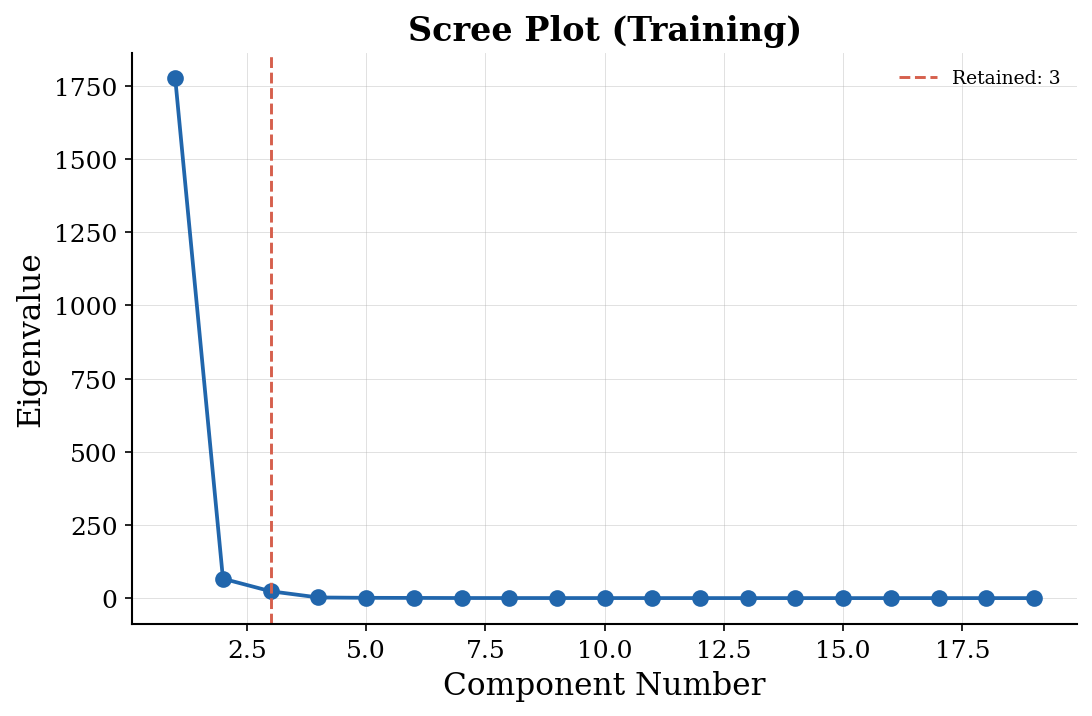

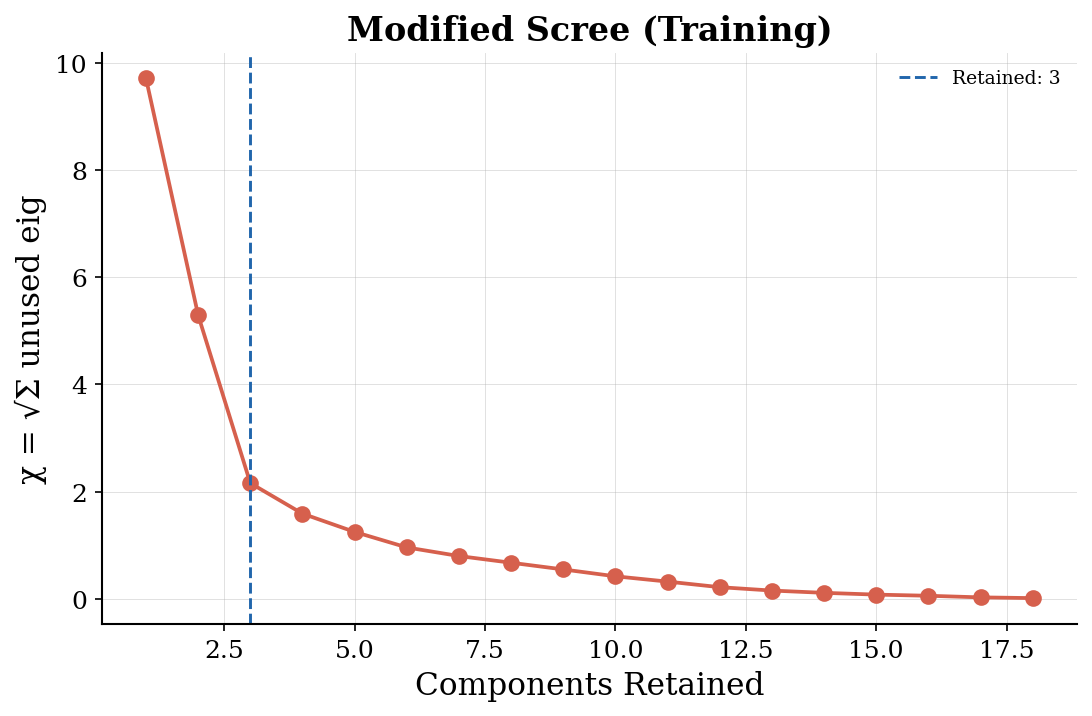

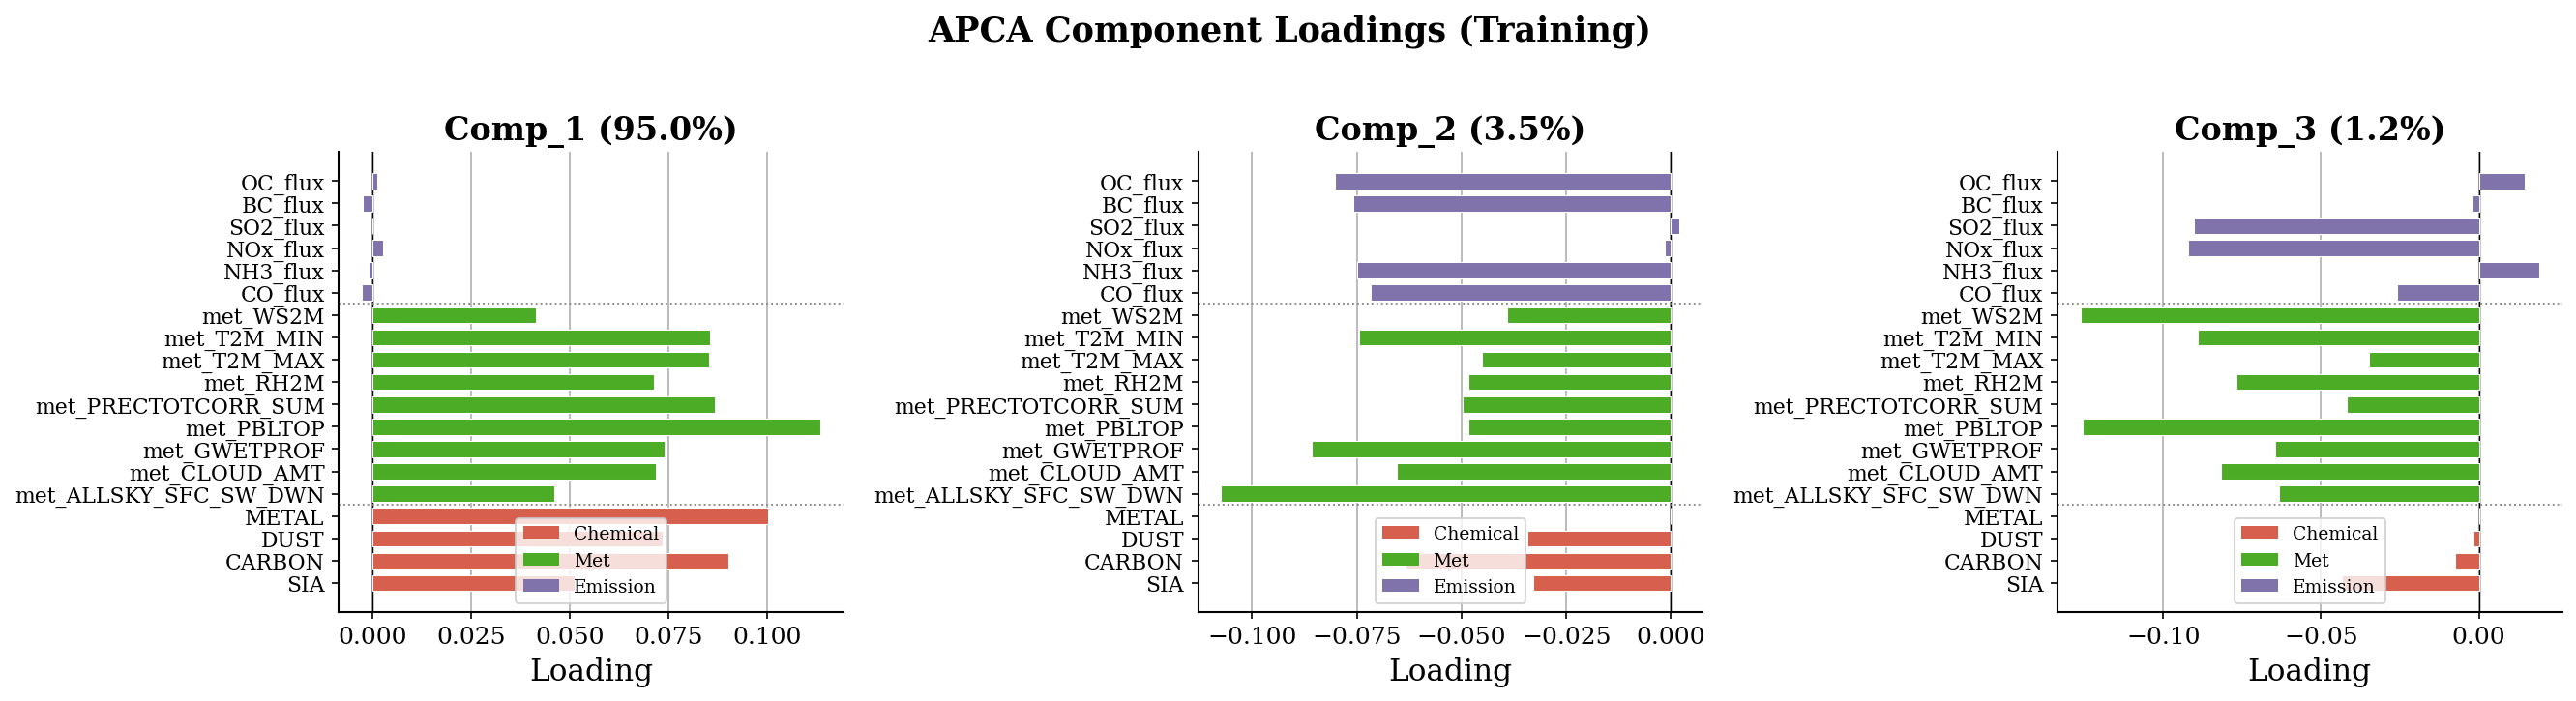

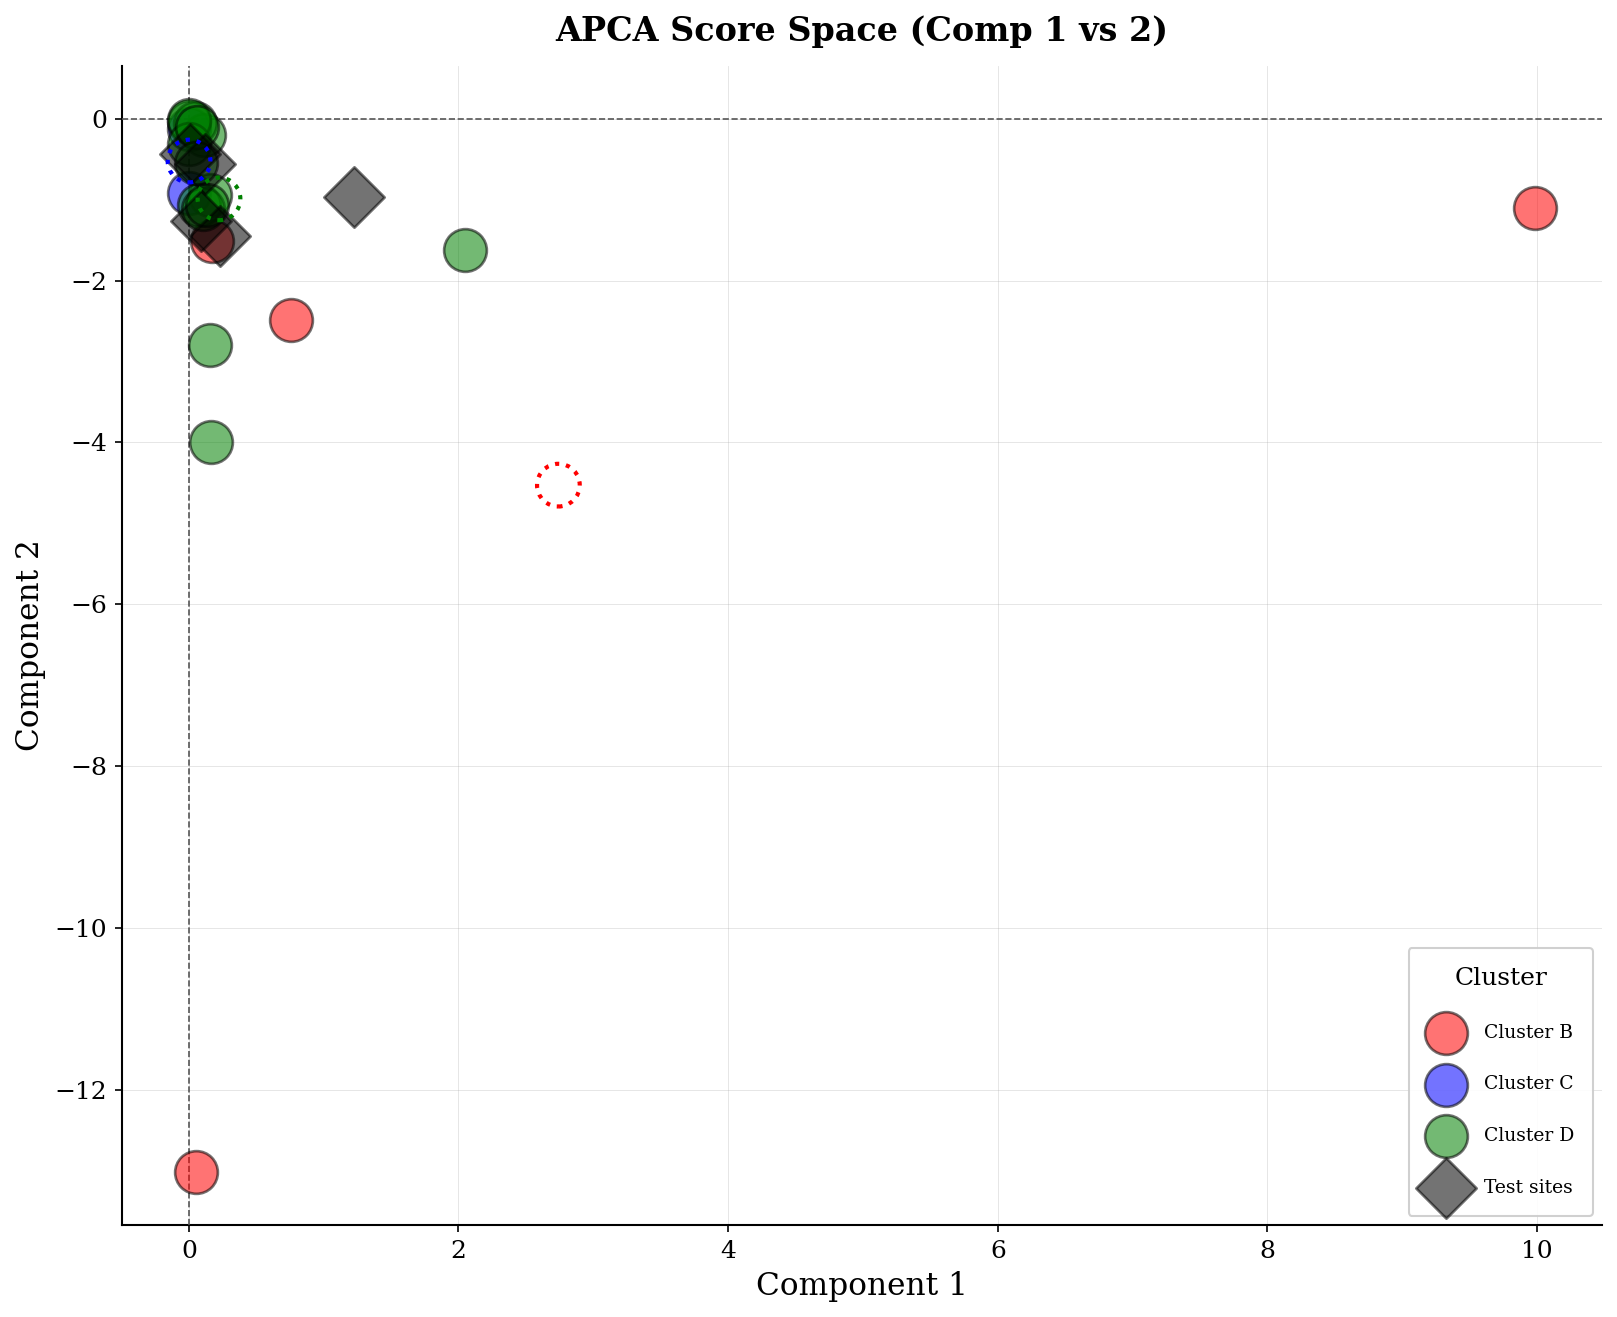

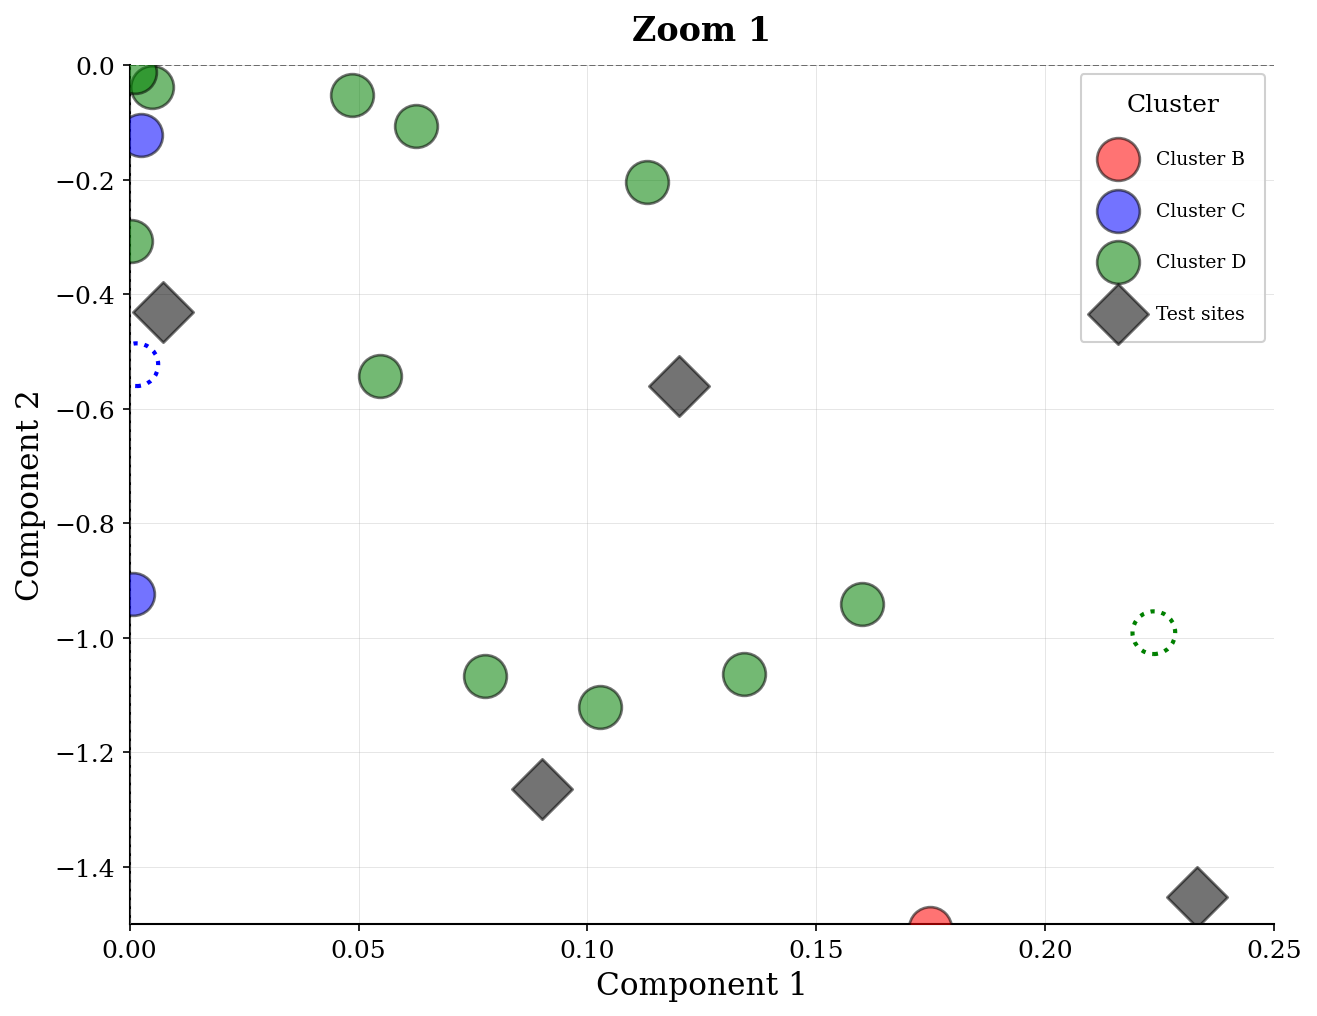

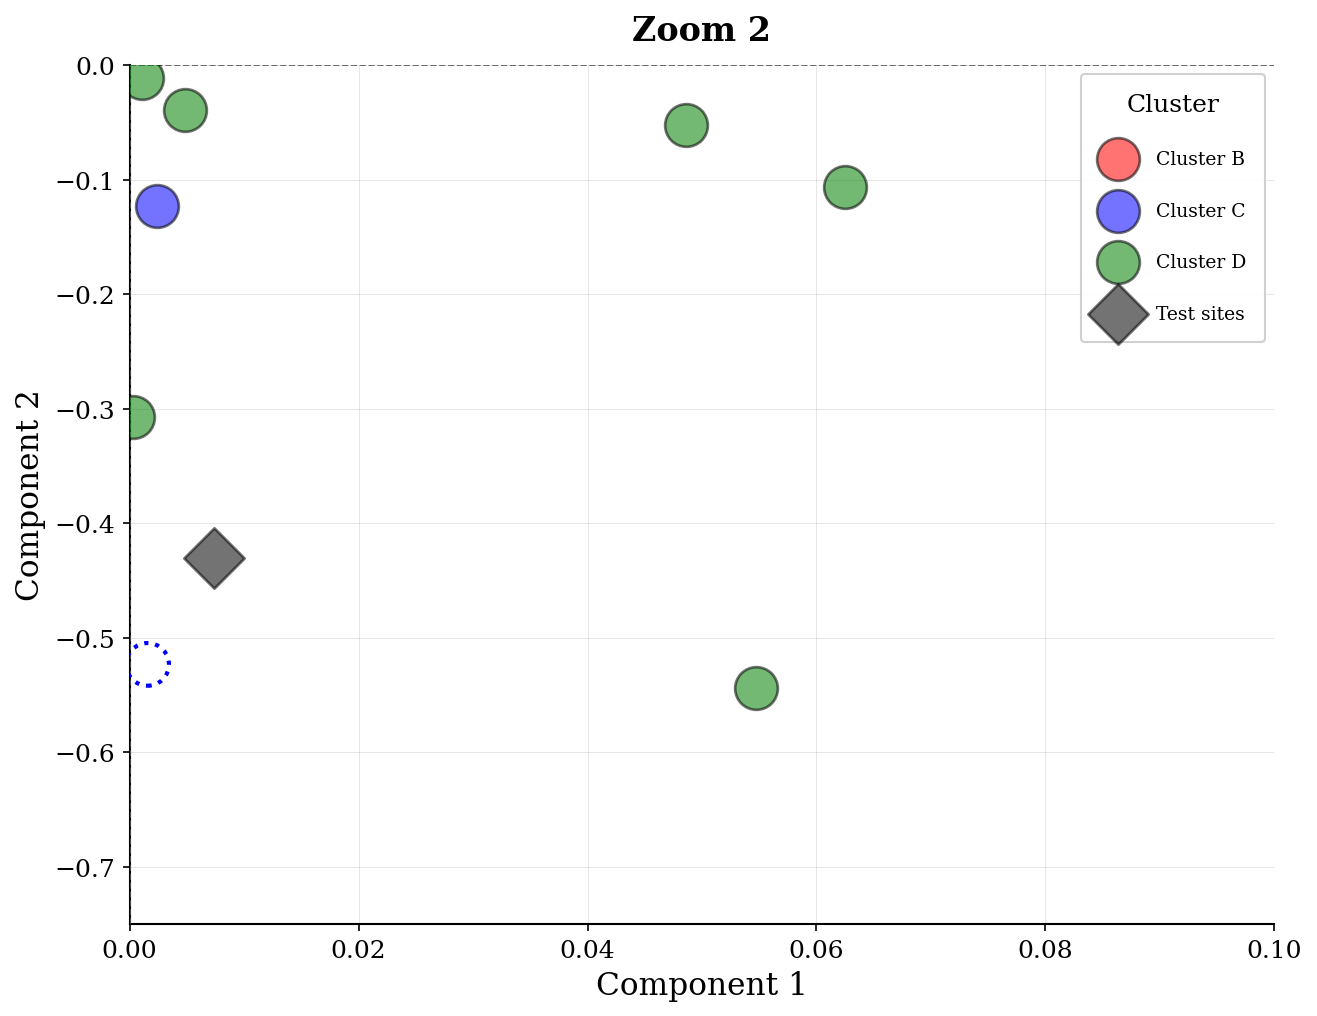

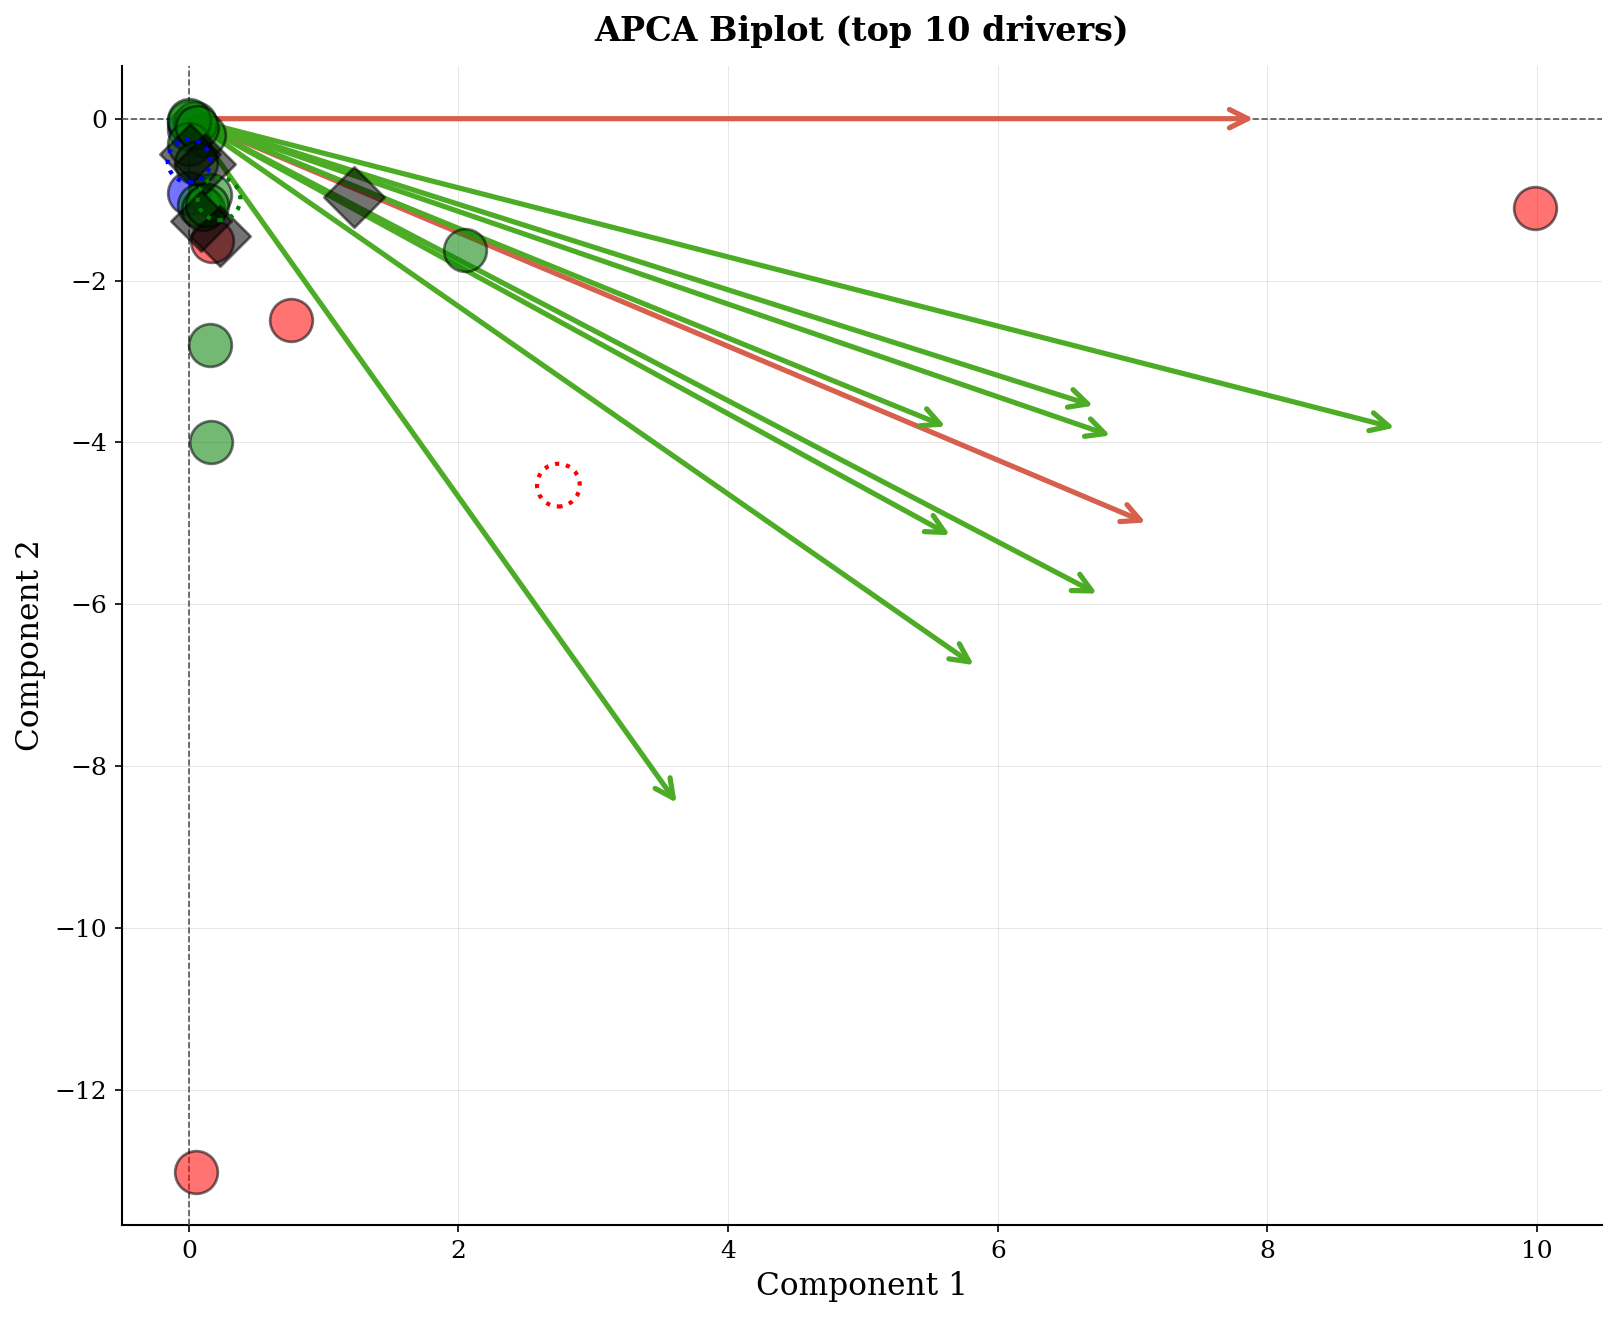

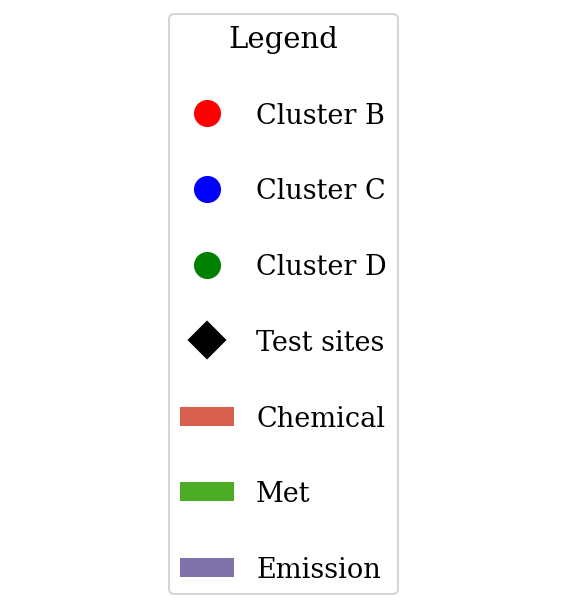

Saved 8 images to /content/drive/MyDrive/Data/apca_outputs


In [ ]:
# ═══ CELL 22: APCA plots as SEPARATE images ═══
import numpy as np, matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import warnings; warnings.filterwarnings('ignore')

rcParams.update({'font.family':'serif','font.serif':['DejaVu Serif','Georgia'],
    'font.size':14,'axes.titlesize':16,'axes.titleweight':'bold','axes.labelsize':15,
    'axes.linewidth':1.0,'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight','pdf.fonttype':42,'ps.fonttype':42})

#### ===== EDITABLE SETTINGS =====
DOT_SIZE      = 420      #### marker size
DOT_ALPHA     = 0.55     #### transparency (lower = more see-through)
EDGE_COLOR    = 'black'  #### solid edge color
EDGE_WIDTH    = 1.3      #### edge thickness
ZOOM1_XLIM    = (0, 0.25)   #### zoom1 x-range  (your [0.4, -1.75])
ZOOM1_YLIM    = (-1.5, 0)    #### zoom1 y-range  (adjust as needed)
ZOOM2_XLIM    = (0, 0.1)   #### zoom2 x-range  (your [0.25, -1])
ZOOM2_YLIM    = (-0.75, 0)    #### zoom2 y-range  (adjust as needed)
LEGEND_SPACING= 1.8      #### vertical gap between legend dots (labelspacing)
#### =============================

def draw_scatter(ax, tdf, x_col, y_col, cluster_map, colors, test_df=None,
                 xlim=None, ylim=None, show_legend=True, title=None):
    if tdf.index.duplicated().any(): tdf=tdf.groupby(tdf.index).mean()
    xv=tdf[x_col].to_numpy(float); yv=tdf[y_col].to_numpy(float); locs=tdf.index.tolist()
    clusters=np.array([cluster_map.get(l,-1) for l in locs])
    ax.axhline(0,color='#555555',lw=0.8,ls='--',zorder=3); ax.axvline(0,color='#555555',lw=0.8,ls='--',zorder=3)
    ax.grid(True,lw=0.4,alpha=0.35,color='#AAAAAA',zorder=0)
    for cid in sorted(set(clusters), key=lambda c:CLUSTER_LABELS.get(c,str(c))):
        m=clusters==cid
        if m.any():
            ax.scatter(xv[m],yv[m],color=colors.get(cid,'#AAAAAA'),
                       alpha=DOT_ALPHA, edgecolors=EDGE_COLOR, s=DOT_SIZE, linewidths=EDGE_WIDTH,
                       zorder=10, label=f'Cluster {CLUSTER_LABELS.get(cid,cid)}')
    for cid in centroids.index:
        ax.scatter(centroids.loc[cid,x_col],centroids.loc[cid,y_col],s=DOT_SIZE,facecolors='none',
                   edgecolors=colors.get(cid,'#AAAAAA'),linewidths=2.0,linestyles='dotted',zorder=30)
    if test_df is not None:
        ax.scatter(test_df[x_col],test_df[y_col],color='black',marker='D',s=DOT_SIZE,
                   alpha=DOT_ALPHA, edgecolors=EDGE_COLOR,linewidths=EDGE_WIDTH,zorder=15,label='Test sites')
    ax.set_xlabel(x_col.replace('Comp_','Component ')); ax.set_ylabel(y_col.replace('Comp_','Component '))
    if title: ax.set_title(title,pad=12)
    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)
    if show_legend:
        ax.legend(title='Cluster',frameon=True,framealpha=0.92,edgecolor='#CCCCCC',
                  loc='best', labelspacing=LEGEND_SPACING, handletextpad=1.0, borderpad=1.0)  #### spacing

S = lambda fn: os.path.join(OUT_DIR, fn)
train_plot=train_scores[comp_names].copy(); test_plot=test_scores[comp_names].copy()

# --- 1. Scree standard ---
ne=len(apca.eigenvalues_); chi=np.array([np.sqrt(np.sum(apca.eigenvalues_[j:])) for j in range(1,ne)])
fig,ax=plt.subplots(figsize=(7.5,5))
ax.plot(range(1,ne+1),apca.eigenvalues_,'o-',color='#2166AC',lw=1.8,ms=7)
ax.axvline(nc,color='#D6604D',ls='--',lw=1.4,label=f'Retained: {nc}')
ax.set_xlabel('Component Number'); ax.set_ylabel('Eigenvalue'); ax.set_title('Scree Plot (Training)')
ax.legend(frameon=False); ax.grid(True,lw=0.45,alpha=0.4)
fig.tight_layout(); fig.savefig(S('scree_standard.png')); plt.show()

# --- 2. Scree modified ---
fig,ax=plt.subplots(figsize=(7.5,5))
ax.plot(range(1,len(chi)+1),chi,'o-',color='#D6604D',lw=1.8,ms=7)
ax.axvline(nc,color='#2166AC',ls='--',lw=1.4,label=f'Retained: {nc}')
ax.set_xlabel('Components Retained'); ax.set_ylabel('χ = √Σ unused eig'); ax.set_title('Modified Scree (Training)')
ax.legend(frameon=False); ax.grid(True,lw=0.45,alpha=0.4)
fig.tight_layout(); fig.savefig(S('scree_modified.png')); plt.show()

# --- 3. Loadings bars ---
ncols=min(3,nc); nrows=int(np.ceil(nc/ncols))
fig,axes=plt.subplots(nrows,ncols,figsize=(6.0*ncols,4.8*nrows)); axes=np.array(axes).flatten()
for k,col in enumerate(comp_names):
    ax=axes[k]; vals=loadings_df[col].values
    ax.barh(range(len(ALL_PARAMS)),vals,color=[GROUP_COLORS.get(p,'#888888') for p in ALL_PARAMS],
            edgecolor='white',linewidth=0.5,height=0.72,zorder=3)
    ax.set_yticks(range(len(ALL_PARAMS))); ax.set_yticklabels(ALL_PARAMS,fontsize=10.5)
    ax.axvline(0,color='black',lw=0.7); ax.set_title(f'{col} ({apca.explained_variance_ratio_[k]:.1%})')
    ax.set_xlabel('Loading'); ax.grid(axis='x',zorder=0)
    for b in boundaries: ax.axhline(b-0.5,color='#888888',lw=0.9,ls=':')
    ax.legend(handles=[Patch(facecolor='#D6604D',label='Chemical'),Patch(facecolor='#4DAC26',label='Met'),
              Patch(facecolor='#8073AC',label='Emission')],fontsize=9,loc='lower center')
for k in range(nc,len(axes)): axes[k].set_visible(False)
fig.suptitle('APCA Component Loadings (Training)',fontweight='bold',y=1.01)
fig.tight_layout(); fig.savefig(S('loadings_bars.png')); plt.show()

# --- 4. Full scatter ---
fig,ax=plt.subplots(figsize=(11,9))
draw_scatter(ax,train_plot,'Comp_1','Comp_2',location_cluster_map,CLUSTER_COLORS,
             test_df=test_plot,title='APCA Score Space (Comp 1 vs 2)')
fig.tight_layout(); fig.savefig(S('scatter_full.png')); plt.show()

# --- 5. Zoom 1 ---
fig,ax=plt.subplots(figsize=(9,7))
draw_scatter(ax,train_plot,'Comp_1','Comp_2',location_cluster_map,CLUSTER_COLORS,test_df=test_plot,
             xlim=ZOOM1_XLIM, ylim=ZOOM1_YLIM, title='Zoom 1')
fig.tight_layout(); fig.savefig(S('scatter_zoom1.png')); plt.show()

# --- 6. Zoom 2 ---
fig,ax=plt.subplots(figsize=(9,7))
draw_scatter(ax,train_plot,'Comp_1','Comp_2',location_cluster_map,CLUSTER_COLORS,test_df=test_plot,
             xlim=ZOOM2_XLIM, ylim=ZOOM2_YLIM, title='Zoom 2')
fig.tight_layout(); fig.savefig(S('scatter_zoom2.png')); plt.show()

# --- 7. Biplot (NO names on arrows) ---
fig,ax=plt.subplots(figsize=(11,9))
draw_scatter(ax,train_plot,'Comp_1','Comp_2',location_cluster_map,CLUSTER_COLORS,
             test_df=test_plot,show_legend=False,title='APCA Biplot (top 10 drivers)')
lx=loadings_df['Comp_1'].values; ly=loadings_df['Comp_2'].values; alen=np.sqrt(lx**2+ly**2)
top=np.argsort(alen)[::-1][:10]   #### change 10 -> number of arrows
sr=max(train_plot['Comp_1'].max()-train_plot['Comp_1'].min(),
       train_plot['Comp_2'].max()-train_plot['Comp_2'].min())*0.5
sf=sr/(alen.max()+1e-9)*1.5       #### arrow length scale
for i in top:
    acol=GROUP_COLORS.get(loadings_df.index[i],'#444444')
    ax.annotate('',xy=(lx[i]*sf,ly[i]*sf),xytext=(0,0),
                arrowprops=dict(arrowstyle='->',color=acol,lw=2.5,mutation_scale=22),zorder=7)
    #### (no text label on arrows)
fig.tight_layout(); fig.savefig(S('biplot.png')); plt.show()

# --- 8. Legend separate ---
fig,ax=plt.subplots(figsize=(4,4)); ax.axis('off')
h=[Line2D([0],[0],marker='o',color='w',markerfacecolor=CLUSTER_COLORS.get(c,'#AAAAAA'),markersize=14,
          label=f'Cluster {CLUSTER_LABELS.get(c,c)}') for c in sorted(centroids.index)]
h.append(Line2D([0],[0],marker='D',color='w',markerfacecolor='black',markersize=14,label='Test sites'))
h+=[Patch(facecolor='#D6604D',label='Chemical'),Patch(facecolor='#4DAC26',label='Met'),Patch(facecolor='#8073AC',label='Emission')]
ax.legend(handles=h,loc='center',frameon=True,fontsize=13,title='Legend',title_fontsize=14,
          labelspacing=LEGEND_SPACING)  #### spacing
fig.tight_layout(); fig.savefig(S('legend.png')); plt.show()
print("Saved 8 images to", OUT_DIR)

In [ ]:
# ═══ CELL : Print coordinates (scores + biplot arrow tips) ═══
import numpy as np, pandas as pd

print("="*70)
print("SCORE COORDINATES — Training locations (Comp_1, Comp_2, Comp_3)")
print("="*70)
for loc in train_scores.index:
    cid = train_scores.loc[loc,'Cluster']
    lbl = CLUSTER_LABELS.get(int(cid),str(cid)) if pd.notna(cid) else 'N/A'
    print(f"  {loc:30} C1={train_scores.loc[loc,'Comp_1']:>8.4f}  "
          f"C2={train_scores.loc[loc,'Comp_2']:>8.4f}  C3={train_scores.loc[loc,'Comp_3']:>8.4f}  [{lbl}]")

print("\n"+"="*70)
print("SCORE COORDINATES — Test locations")
print("="*70)
for loc in test_scores.index:
    print(f"  {loc:30} C1={test_scores.loc[loc,'Comp_1']:>8.4f}  "
          f"C2={test_scores.loc[loc,'Comp_2']:>8.4f}  C3={test_scores.loc[loc,'Comp_3']:>8.4f}")

print("\n"+"="*70)
print("CENTROID COORDINATES")
print("="*70)
for cid in centroids.index:
    print(f"  Cluster {CLUSTER_LABELS.get(cid,cid):3} "
          f"C1={centroids.loc[cid,'Comp_1']:>8.4f}  C2={centroids.loc[cid,'Comp_2']:>8.4f}")

print("\n"+"="*70)
print("BIPLOT ARROW COORDINATES (loading tip in Comp_1/Comp_2 space)")
print("  raw_loading = unscaled; tip = scaled as drawn in biplot")
print("="*70)
lx=loadings_df['Comp_1'].values; ly=loadings_df['Comp_2'].values; alen=np.sqrt(lx**2+ly**2)
sr=max(train_scores['Comp_1'].max()-train_scores['Comp_1'].min(),
       train_scores['Comp_2'].max()-train_scores['Comp_2'].min())*0.5
sf=sr/(alen.max()+1e-9)*1.5
order=np.argsort(alen)[::-1]
print(f"  {'Variable':24} {'rawC1':>9} {'rawC2':>9} {'tipC1':>9} {'tipC2':>9} {'length':>8}")
for i in order:
    v=loadings_df.index[i]
    print(f"  {v:24} {lx[i]:>9.4f} {ly[i]:>9.4f} {lx[i]*sf:>9.4f} {ly[i]*sf:>9.4f} {alen[i]:>8.4f}")

# also save as CSV
pd.DataFrame({'Variable':loadings_df.index,'rawC1':lx,'rawC2':ly,
              'tipC1':lx*sf,'tipC2':ly*sf,'length':alen}).to_csv(
    os.path.join(OUT_DIR,'biplot_arrow_coords.csv'), index=False)
print("\nSaved biplot_arrow_coords.csv")

SCORE COORDINATES — Training locations (Comp_1, Comp_2, Comp_3)
  Abu Dhabi, UAE                 C1=  0.1129  C2= -0.2035  C3= -0.2102  [D]
  Addis Ababa, Ethiopia          C1=  0.0513  C2=-13.0204  C3= -1.4289  [B]
  Bandung, Indonesia             C1=  0.1749  C2= -1.5072  C3= -0.5801  [B]
  Beijing, China                 C1=  0.1558  C2= -2.8015  C3= -1.3294  [D]
  Bujumbura, Burundi             C1=  0.1600  C2= -0.9414  C3= -0.4055  [D]
  Dhaka, Bangladesh              C1=  9.9819  C2= -1.0983  C3= -0.1083  [B]
  Fajardo, Puerto Rico           C1=  0.0048  C2= -0.0393  C3= -0.0558  [D]
  Haifa, Israel                  C1=  0.0486  C2= -0.0527  C3= -0.0444  [D]
  Halifax, Canada                C1=  0.0011  C2= -0.0115  C3= -0.0198  [D]
  Ilorin, Nigeria                C1=  2.0513  C2= -1.6231  C3= -0.0677  [D]
  Kanpur, India                  C1=  0.7555  C2= -2.4869  C3= -0.5401  [B]
  Kaohsiung, Taiwan              C1=  0.1653  C2= -3.9958  C3=-11.4879  [D]
  Mexico City, Mexico   

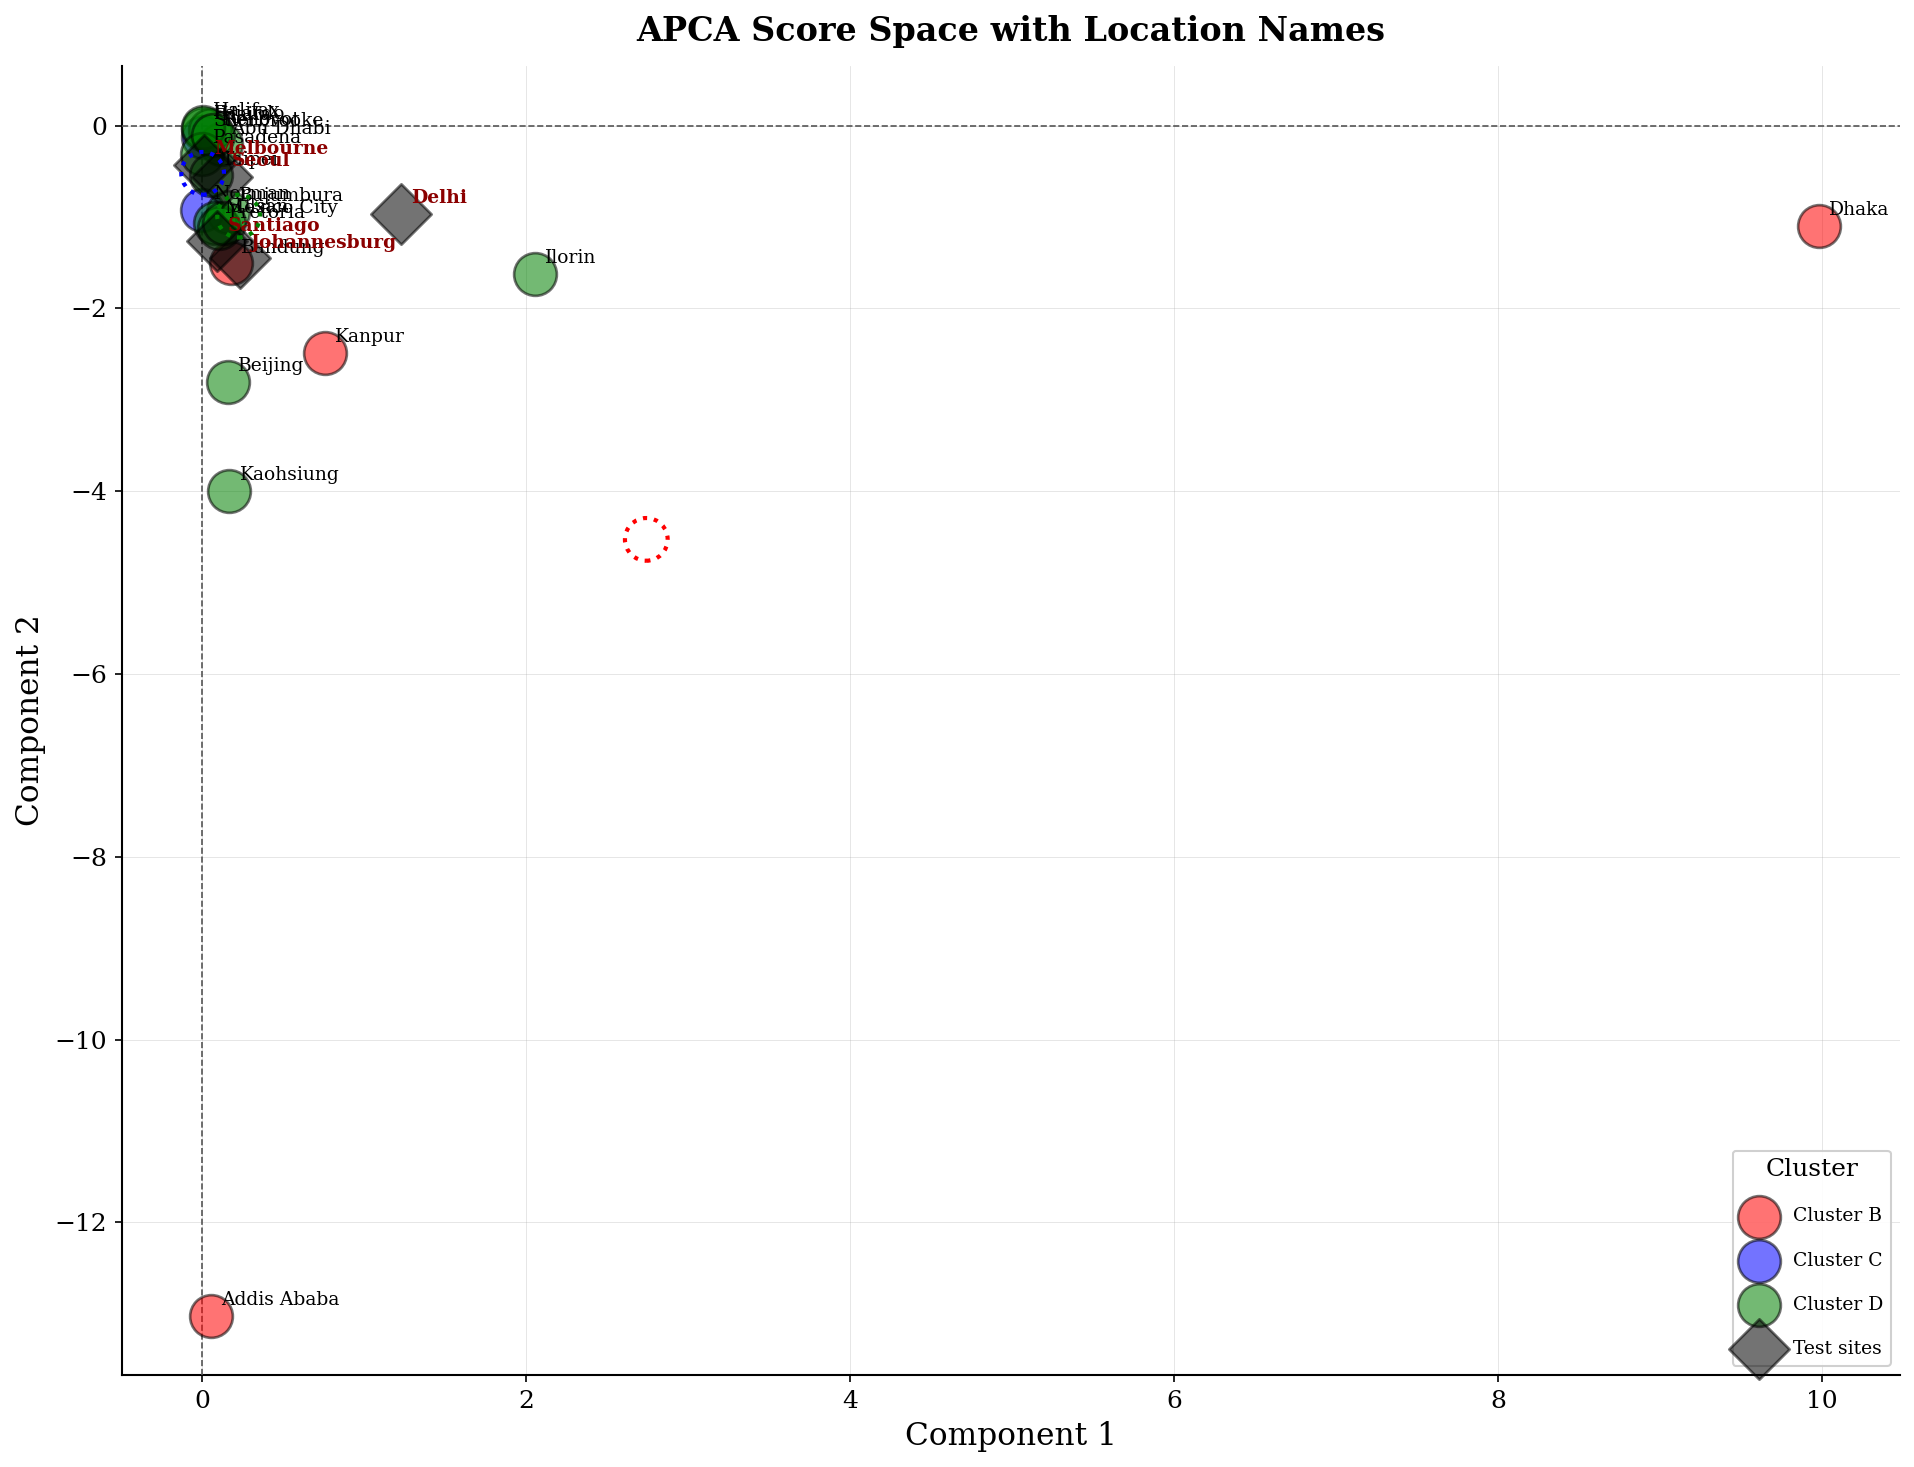

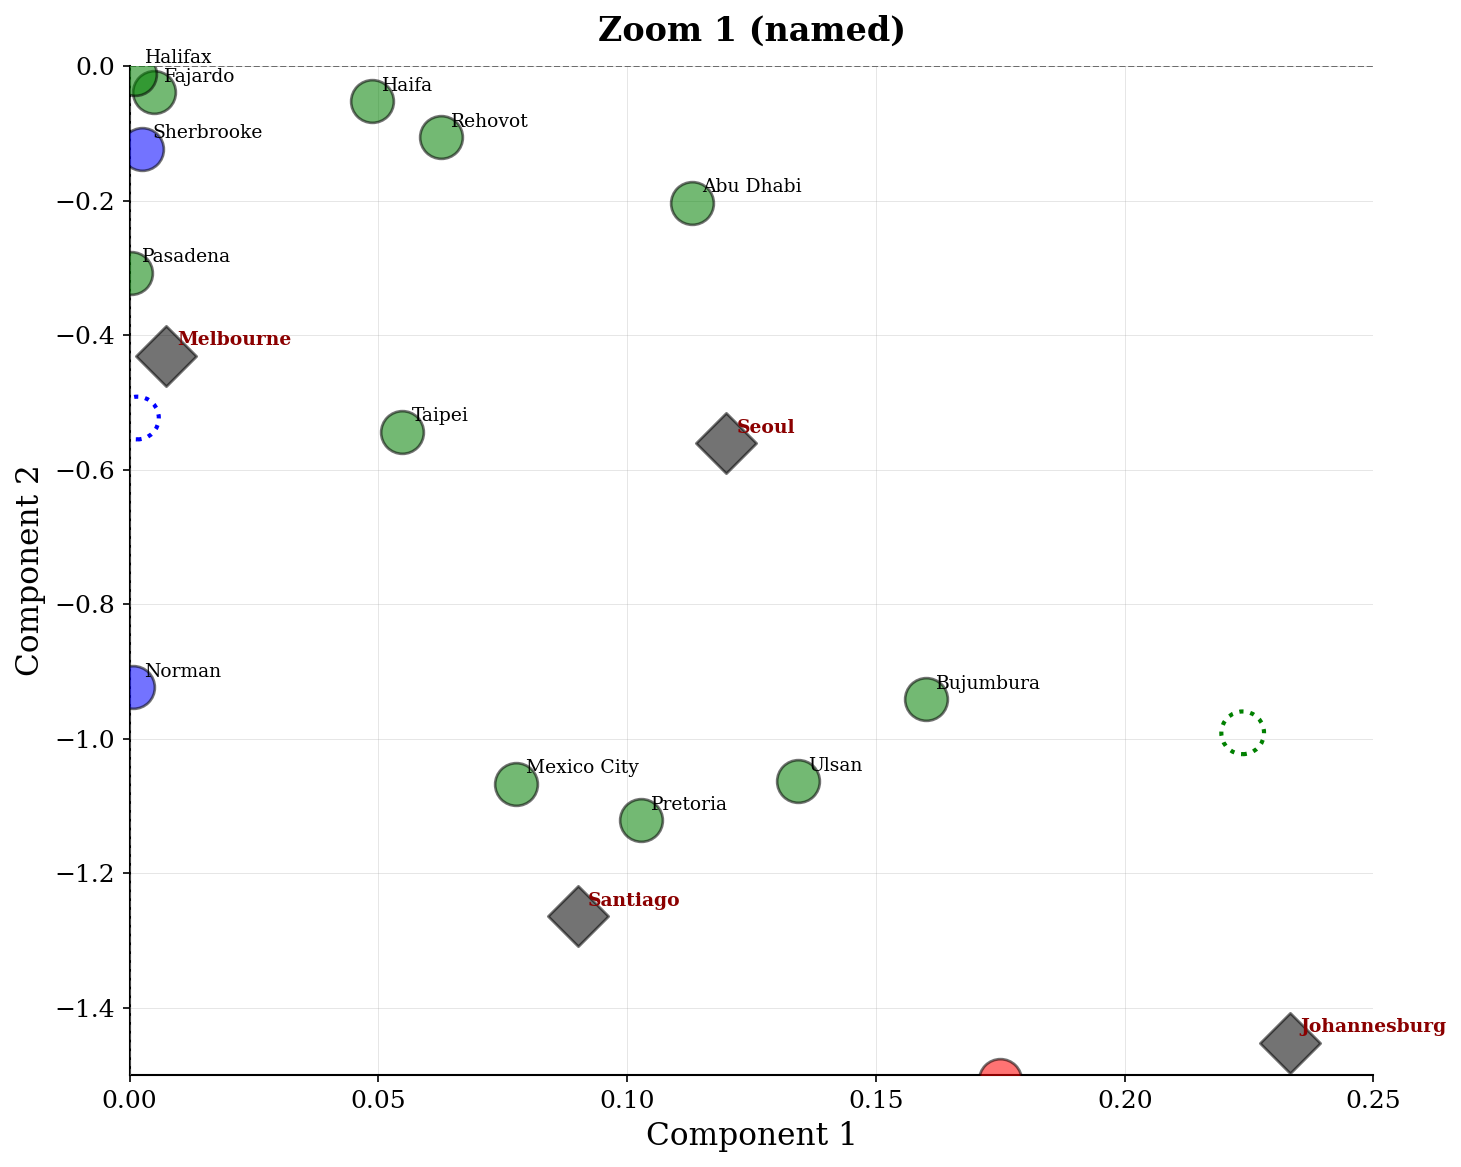

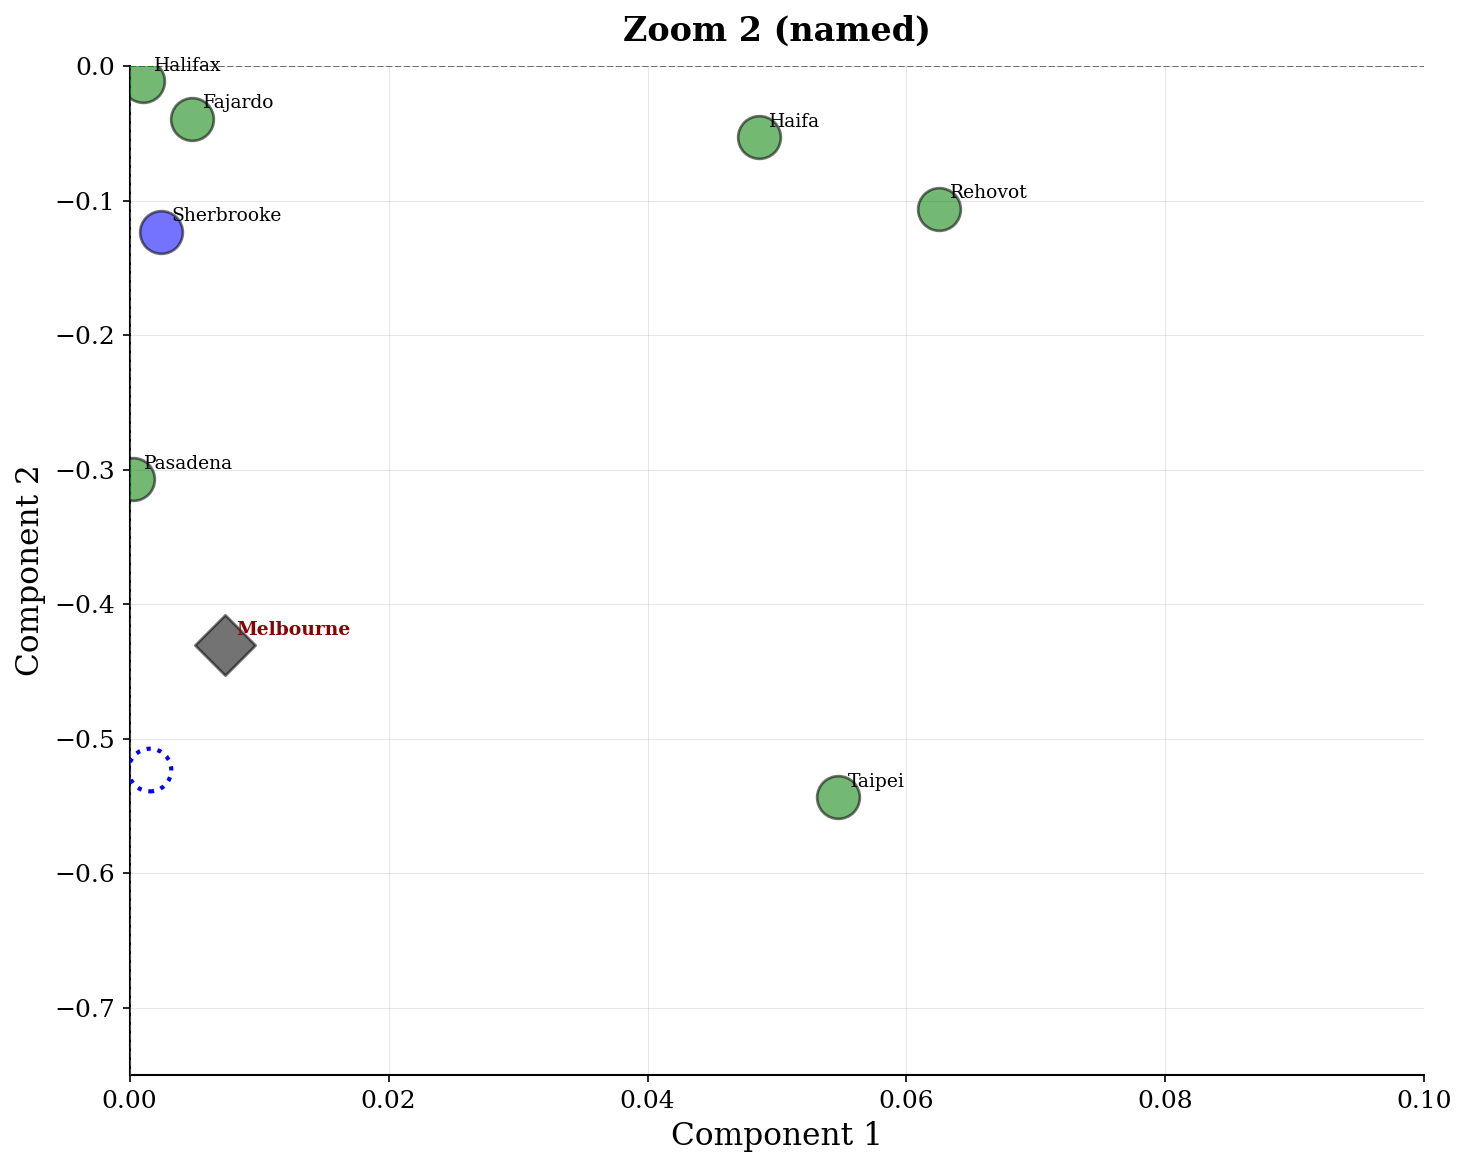

In [ ]:
# ═══ CELL: Scatter WITH names — main + zoom insets (print only) ═══
# Requires ZOOM1_XLIM/YLIM, ZOOM2_XLIM/YLIM from Cell 3 (run Cell 3 first)
import numpy as np, matplotlib.pyplot as plt

def _plot_named(ax, xlim=None, ylim=None, title=None, label_fs=9):
    tdf = train_scores[comp_names].copy()
    if tdf.index.duplicated().any(): tdf = tdf.groupby(tdf.index).mean()
    xv=tdf['Comp_1'].to_numpy(float); yv=tdf['Comp_2'].to_numpy(float); locs=tdf.index.tolist()
    clusters=np.array([location_cluster_map.get(l,-1) for l in locs])
    ax.axhline(0,color='#555555',lw=0.8,ls='--',zorder=3); ax.axvline(0,color='#555555',lw=0.8,ls='--',zorder=3)
    ax.grid(True,lw=0.4,alpha=0.35,color='#AAAAAA',zorder=0)
    for cid in sorted(set(clusters), key=lambda c:CLUSTER_LABELS.get(c,str(c))):
        m=clusters==cid
        if m.any():
            ax.scatter(xv[m],yv[m],color=CLUSTER_COLORS.get(cid,'#AAAAAA'),alpha=0.55,
                       edgecolors='black',s=420,linewidths=1.3,zorder=10,
                       label=f'Cluster {CLUSTER_LABELS.get(cid,cid)}')
    for loc in tdf.index:
        ax.annotate(loc.split(',')[0],(tdf.loc[loc,'Comp_1'],tdf.loc[loc,'Comp_2']),
                    fontsize=label_fs,xytext=(5,5),textcoords='offset points',zorder=20)
    for cid in centroids.index:
        ax.scatter(centroids.loc[cid,'Comp_1'],centroids.loc[cid,'Comp_2'],s=420,facecolors='none',
                   edgecolors=CLUSTER_COLORS.get(cid,'#AAAAAA'),linewidths=2.0,linestyles='dotted',zorder=30)
    ax.scatter(test_scores['Comp_1'],test_scores['Comp_2'],color='black',marker='D',alpha=0.55,
               edgecolors='black',s=420,linewidths=1.3,zorder=15,label='Test sites')
    for loc in test_scores.index:
        ax.annotate(loc.split(',')[0],(test_scores.loc[loc,'Comp_1'],test_scores.loc[loc,'Comp_2']),
                    fontsize=label_fs,fontweight='bold',color='darkred',
                    xytext=(5,5),textcoords='offset points',zorder=20)
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    if title: ax.set_title(title,pad=12)
    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)

# --- main (full range) ---
fig,ax=plt.subplots(figsize=(13,10))
_plot_named(ax, title='APCA Score Space with Location Names')
ax.legend(title='Cluster',frameon=True,framealpha=0.92,edgecolor='#CCCCCC',loc='best',labelspacing=1.4)
fig.tight_layout(); plt.show()

# --- zoom 1 (uses Cell 3 windows) ---
fig,ax=plt.subplots(figsize=(10,8))
_plot_named(ax, xlim=ZOOM1_XLIM, ylim=ZOOM1_YLIM, title='Zoom 1 (named)')
fig.tight_layout(); plt.show()

# --- zoom 2 (uses Cell 3 windows) ---
fig,ax=plt.subplots(figsize=(10,8))
_plot_named(ax, xlim=ZOOM2_XLIM, ylim=ZOOM2_YLIM, title='Zoom 2 (named)')
fig.tight_layout(); plt.show()